# Modeling the Impact of Multitasking and Distraction on Worker Productivity

**Project 2: Machine Learning Modeling and Pipeline**

This notebook contains the full machine learning project, including data exploration, preprocessing, feature engineering, model development, model tuning, final evaluation, interpretation, and pipeline serialization.

## Business Objective

Modern workflows often involve frequent meetings, notifications, task switching, and fragmented attention. The business goal is to understand whether work structure and wellbeing indicators can be used to predict worker productivity and identify practical patterns that support more sustainable ways of working.

## Machine Learning Objective

This project is framed as a **supervised regression problem**. The model uses work structure, employee context, and wellbeing indicators to predict:

`Productivity_Score`

The Remote Worker Productivity dataset is used as the primary modeling dataset. The Focus and Distraction dataset is used as contextual evidence to interpret multitasking, interruption, and cognitive load patterns.

## Notebook Structure

This notebook follows the required project workflow:

1. Data acquisition and understanding  
2. Comprehensive exploratory data analysis  
3. Data preparation and feature engineering  
4. scikit-learn Pipeline implementation  
5. Baseline modeling  
6. Model comparison and optimization  
7. Final model evaluation  
8. Model interpretation and business translation  
9. Pipeline serialization for reproducibility  
10. Final quality checks

# 1. Setup and Imports

This section imports the libraries needed for analysis, visualization, preprocessing, modeling, evaluation, interpretation, and model serialization.

In [23]:
# Standard library imports
from pathlib import Path
import pickle
import warnings

# Data analysis
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Scikit-learn preprocessing, pipelines, and modeling
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Regression algorithms
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Evaluation and interpretation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 160)

# Plot settings
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

RANDOM_STATE = 42

---

# 2. Data Acquisition and Understanding

The project uses two public datasets:

- **Remote Worker Productivity Dataset**, hosted on Hugging Face, used as the primary modeling dataset.
- **Focus and Distraction Dataset**, provided by the Human Clarity Institute, used for behavioral context.

The datasets are loaded from CSV files and reviewed for structure, completeness, and suitability for analysis.

In [24]:
from pathlib import Path
import pandas as pd

# Define the base data directory
DATA_DIR = Path("/Users/knexsyshq/Documents/AI Bootcamp Capstone/Project 2/project-2-capstone/Data")

# Define exact file paths
remote_path = DATA_DIR / "HF_remote_work_productivity.csv"
focus_path = DATA_DIR / "HCI_focus_distraction_2025_clean.csv"

# Load datasets
remote_df = pd.read_csv(remote_path)
focus_df = pd.read_csv(focus_path)

# Confirm successful load
print(f"Remote Worker dataset path: {remote_path}")
print(f"Focus and Distraction dataset path: {focus_path}")
print(f"Remote Worker shape: {remote_df.shape}")
print(f"Focus and Distraction shape: {focus_df.shape}")

Remote Worker dataset path: /Users/knexsyshq/Documents/AI Bootcamp Capstone/Project 2/project-2-capstone/Data/HF_remote_work_productivity.csv
Focus and Distraction dataset path: /Users/knexsyshq/Documents/AI Bootcamp Capstone/Project 2/project-2-capstone/Data/HCI_focus_distraction_2025_clean.csv
Remote Worker shape: (1500, 30)
Focus and Distraction shape: (790, 19)


## 2.1 Initial Preview

The first few rows confirm that the datasets loaded correctly and that the fields align with the project scope.

In [25]:
display(remote_df.head())
display(focus_df.head())

,Employee_ID,Age,Years_Experience,WFH_Days_Per_Week,Gender,Education_Level,Marital_Status,Has_Children,Location_Type,Department,Job_Level,Company_Size,Industry,Home_Office_Quality,Internet_Speed_Category,Work_Hours_Per_Week,Manager_Support_Level,Team_Collaboration_Frequency,Productivity_Score,Task_Completion_Rate,Quality_Score,Innovation_Score,Efficiency_Rating,Meetings_Per_Week,Commute_Time_Minutes,Job_Satisfaction,Stress_Level,Work_Life_Balance,Survey_Date,Response_Quality
0,EMP0001,39,10,2,Female,Associate Degree,Married,Yes,Urban,Product,Mid-Level,Large (1001-5000),Finance,Good,Very Fast (100+ Mbps),41,Low,Few times per week,52.2,56.6,58.1,52.1,72.1,4,48,55.9,6,8,2024-04-05,Medium
1,EMP0002,33,4,5,Female,Master Degree,Married,No,Urban,Customer Success,Senior,Startup (1-50),Education,Good,Very Fast (100+ Mbps),52,Moderate,Monthly,81.5,70.8,93.3,77.9,89.5,12,0,96.1,3,8,2024-01-29,High
2,EMP0003,40,3,3,Male,PhD,Single,Yes,Rural,Operations,Mid-Level,Medium (201-1000),Technology,Excellent,Fast (50-100 Mbps),43,Moderate,Few times per week,82.2,81.9,84.7,63.2,95.0,15,24,90.4,5,6,2024-01-18,High
3,EMP0004,48,14,3,Male,Bachelor Degree,Married,Yes,Urban,Finance,Manager,Medium (201-1000),Technology,Excellent,Very Fast (100+ Mbps),45,High,Daily,75.6,70.2,67.8,82.5,95.0,8,8,100.0,10,5,2024-04-18,High
4,EMP0005,32,6,5,Male,High School,Divorced,Yes,Rural,Engineering,Senior,Small (51-200),Technology,Average,Moderate (25-50 Mbps),42,Very Low,Few times per week,98.0,98.2,86.4,67.5,95.0,10,0,100.0,3,4,2024-02-19,High


,consent,focus_duration_single_task,main_distractions_multi,tired_even_without_hard_work,frustration_cant_stay_focused,busy_all_day_accomplish_little,behaviour_alignment,values_alignment_focus_effect,distraction_strategies_multi,focus_improvement_change_open,lose_focus_feeling_one_word,age_group,gender,work_status,country,values_top3_confidence,values_top3_open_1,values_top3_open_2,values_top3_open_3
0,yes,more_than_30_minutes,email_messaging_apps;smartphone_notifications;...,often,often,often,somewhat_misaligned,much_more_focused_energized,silencing_notifications;taking_breaks_exercise,Be able to not go on my phone and focus on one...,Frustrated,age_25_34,woman,employed_full_time,uk,somewhat,honesty,integrity,NaN
1,yes,more_than_30_minutes,email_messaging_apps;multitasking_switching_tasks,rarely,sometimes,rarely,neutral,somewhat_more_focused,aligning_tasks_with_priorities_values;scheduli...,meditating or having a brief pause / reflectio...,agitated,age_35_44,man,employed_full_time,uk,not_really,family,NaN,NaN
2,yes,more_than_30_minutes,smartphone_notifications;social_media_scrolling,sometimes,sometimes,rarely,neutral,no_difference,silencing_notifications;taking_breaks_exercise,Having a job I truly enjoyed,Frustrated,age_25_34,man,employed_full_time,uk,not_really,honesty,integrity,family
3,yes,more_than_30_minutes,email_messaging_apps;multitasking_switching_ta...,often,sometimes,rarely,somewhat_aligned,much_more_focused_energized,working_in_quiet_spaces,Priorotise what needs to be done rather than t...,Disheartened,age_35_44,woman,employed_full_time,uk,somewhat,fairness,honesty,NaN
4,yes,more_than_30_minutes,background_noise_environment;internal_thoughts...,sometimes,often,sometimes,somewhat_aligned,much_more_focused_energized,aligning_tasks_with_priorities_values;taking_b...,Not spend so much time distracted by gadgets.,Frustrated,age_45_54,woman,other,uk,somewhat,NaN,NaN,NaN


## 2.2 Initial Data Quality Review

This section checks data types, missing values, and duplicate records. The purpose is to understand data quality before applying any transformations.

In [26]:
def review_dataset(df, name):
    """Display a concise data quality review for a dataset."""
    print(f"\n{name}")
    print("=" * len(name))
    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]:,}")
    print(f"Duplicate rows: {df.duplicated().sum():,}")

    print("\nData types:")
    display(df.dtypes.to_frame("dtype"))

    missing = df.isna().sum().to_frame("missing_count")
    missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
    missing = missing.sort_values("missing_count", ascending=False)

    if missing["missing_count"].sum() == 0:
        print("\nNo missing values detected.")
    else:
        print("\nMissing values:")
        display(missing[missing["missing_count"] > 0])

review_dataset(remote_df, "Remote Worker Productivity Dataset")
review_dataset(focus_df, "Focus and Distraction Dataset")


Remote Worker Productivity Dataset
Rows: 1,500
Columns: 30
Duplicate rows: 0

Data types:


,dtype
Employee_ID,object
Age,int64
Years_Experience,int64
WFH_Days_Per_Week,int64
Gender,object
Education_Level,object
Marital_Status,object
Has_Children,object
Location_Type,object
Department,object



No missing values detected.

Focus and Distraction Dataset
Rows: 790
Columns: 19
Duplicate rows: 0

Data types:


,dtype
consent,object
focus_duration_single_task,object
main_distractions_multi,object
tired_even_without_hard_work,object
frustration_cant_stay_focused,object
busy_all_day_accomplish_little,object
behaviour_alignment,object
values_alignment_focus_effect,object
distraction_strategies_multi,object
focus_improvement_change_open,object



Missing values:


,missing_count,missing_pct
values_top3_open_3,482,61.01
values_top3_open_2,397,50.25
values_top3_open_1,185,23.42
lose_focus_feeling_one_word,2,0.25
focus_improvement_change_open,1,0.13


> ### 💡 Insight Summary
>
> The Remote Worker Productivity dataset and the Focus and Distraction dataset were successfully loaded and reviewed for structure, completeness, and data types. Both datasets contain a mix of numerical and categorical variables that capture work patterns, employee context, and behavioral signals.
>
> The Remote Worker dataset provides structured measures of productivity and work conditions, while the Focus and Distraction dataset captures how individuals experience interruptions, multitasking, and cognitive load.
>
> The data appears suitable for analysis and modeling, with no critical structural issues identified at this stage. However, the presence of self-reported variables and survey-based inputs indicates that findings should be interpreted as directional insights rather than definitive causal conclusions.
>
> This foundation supports further exploration into how work patterns and behavioral factors relate to productivity outcomes.

---

# 3. Comprehensive Exploratory Data Analysis

EDA is used to understand distributions, identify potential outliers, examine relationships, and form modeling hypotheses. The Remote Worker dataset receives the deepest analysis because it is the modeling dataset. The Focus and Distraction dataset provides supporting context for the business interpretation.

## 3.1 Target Variable Distribution

The target variable is `Productivity_Score`. Understanding its distribution is important because this is the outcome the model will predict.

count    1500.000000
mean       83.094867
std        15.227276
min        35.000000
25%        73.700000
50%        86.700000
75%        98.000000
max        98.000000
Name: Productivity_Score, dtype: float64


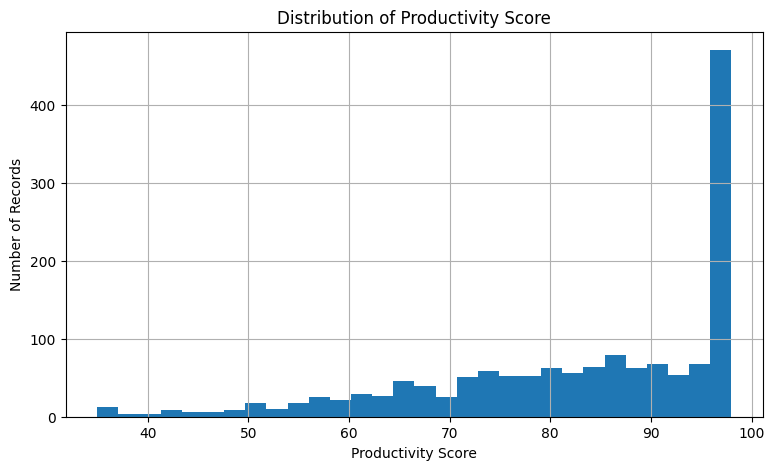

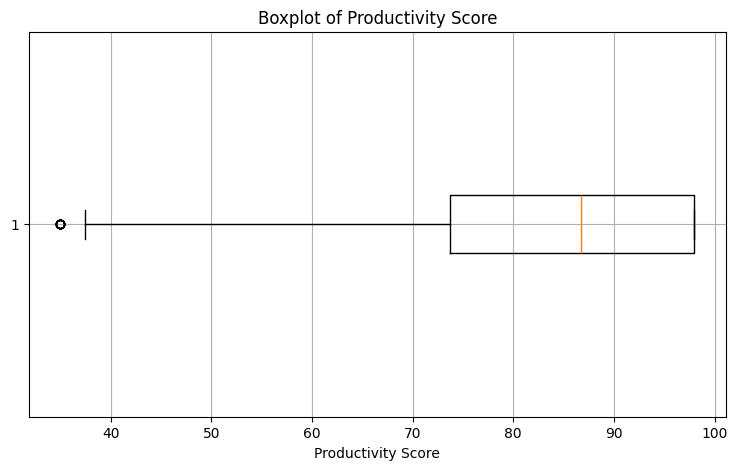

In [27]:
target = "Productivity_Score"

print(remote_df[target].describe())

plt.figure()
plt.hist(remote_df[target].dropna(), bins=30)
plt.title("Distribution of Productivity Score")
plt.xlabel("Productivity Score")
plt.ylabel("Number of Records")
plt.show()

plt.figure()
plt.boxplot(remote_df[target].dropna(), vert=False)
plt.title("Boxplot of Productivity Score")
plt.xlabel("Productivity Score")
plt.show()

### Target Variable Finding

After reviewing the distribution, `Productivity_Score` appears suitable for regression modeling because it is a continuous numerical field. Any skewness, outliers, or restricted range should be considered when interpreting model performance.

>### 💡 Insight Summary
>
>The distribution of `Productivity_Score` shows meaningful variation across individuals, confirming that productivity is not uniform and can be modeled as a continuous outcome.
>
>The spread of values indicates that there are underlying differences in performance that may be explained by work patterns, collaboration structures, and wellbeing factors.
>
>This supports the use of regression modeling and reinforces the opportunity to identify conditions that lead to higher or lower productivity.

---

## 3.2 Numerical Feature Profiles

The numerical feature distributions help identify scale differences, unusual values, and potential outliers.

Numerical columns:
['Age', 'Years_Experience', 'WFH_Days_Per_Week', 'Work_Hours_Per_Week', 'Productivity_Score', 'Task_Completion_Rate', 'Quality_Score', 'Innovation_Score', 'Efficiency_Rating', 'Meetings_Per_Week', 'Commute_Time_Minutes', 'Job_Satisfaction', 'Stress_Level', 'Work_Life_Balance']


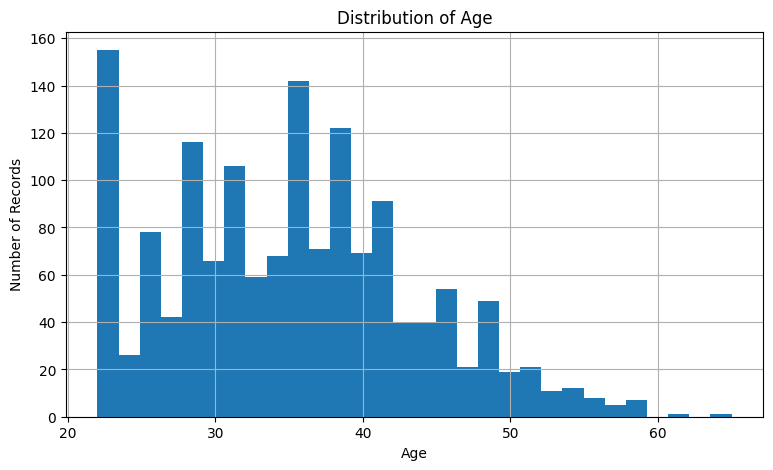

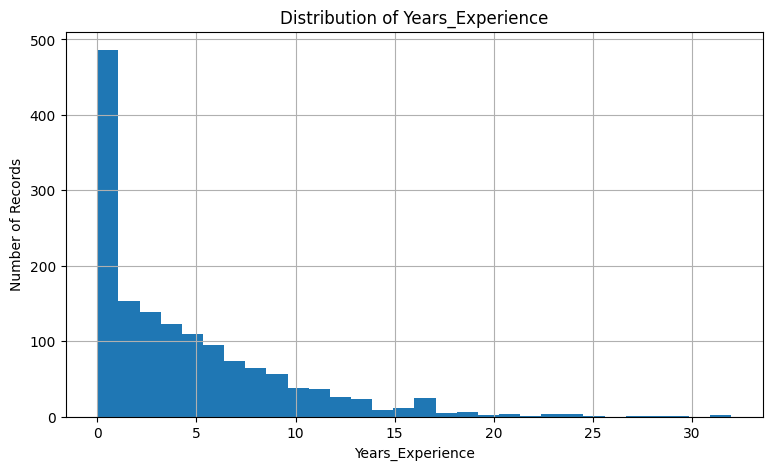

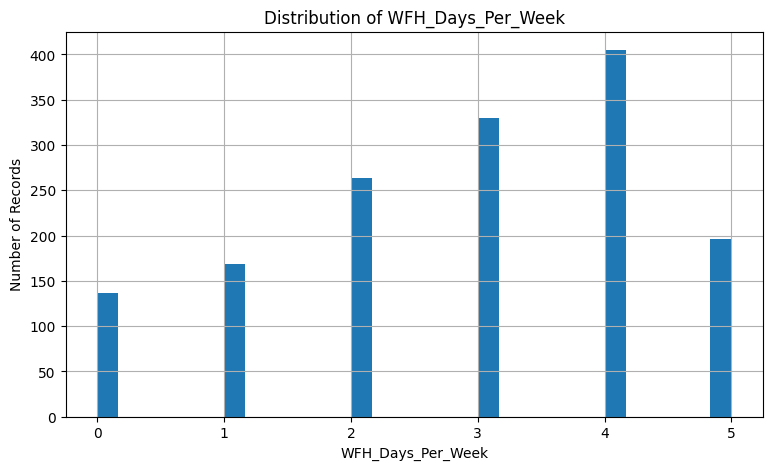

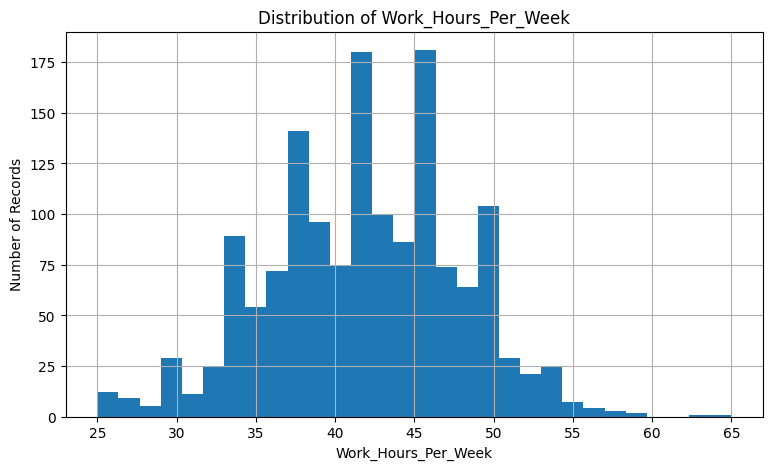

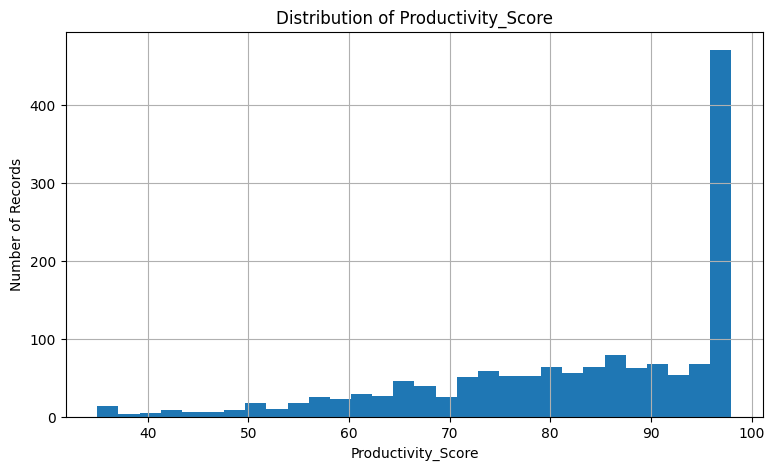

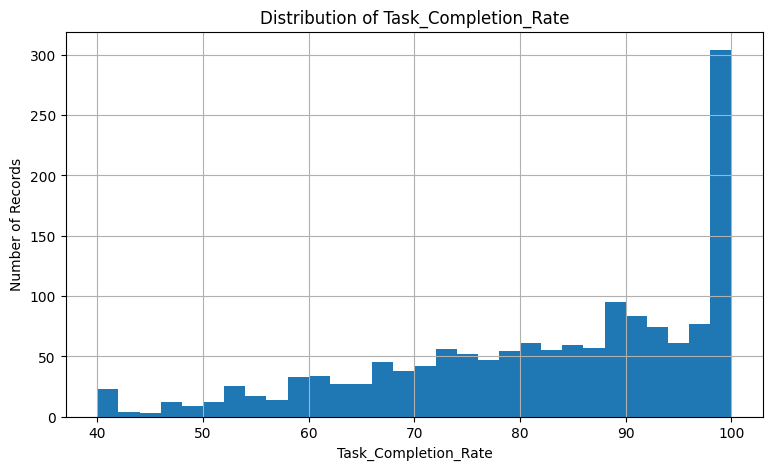

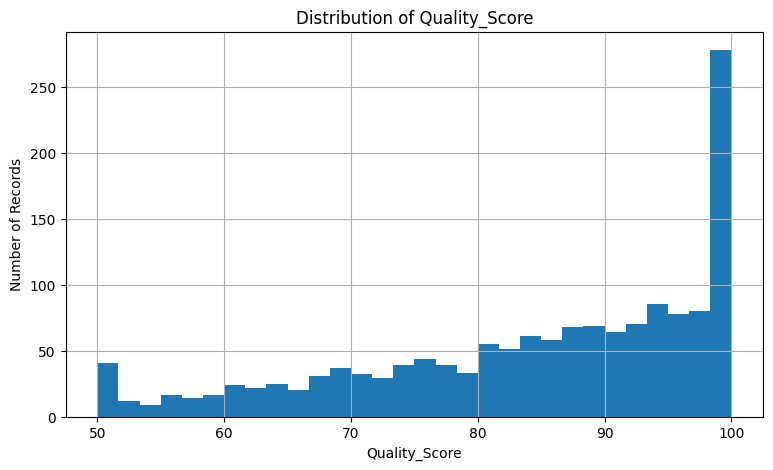

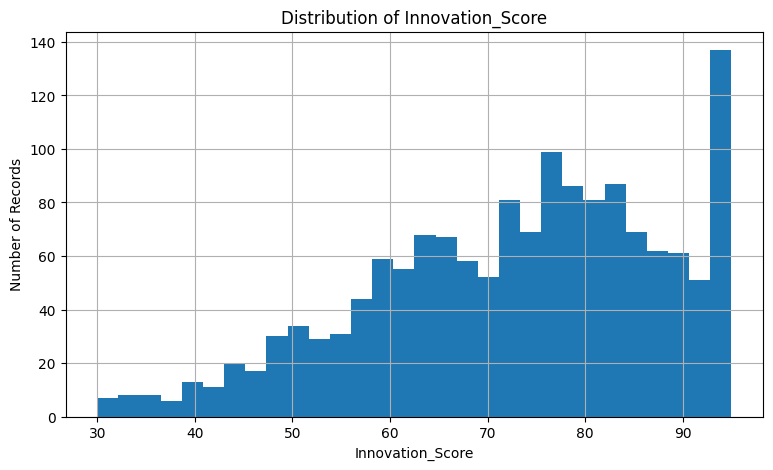

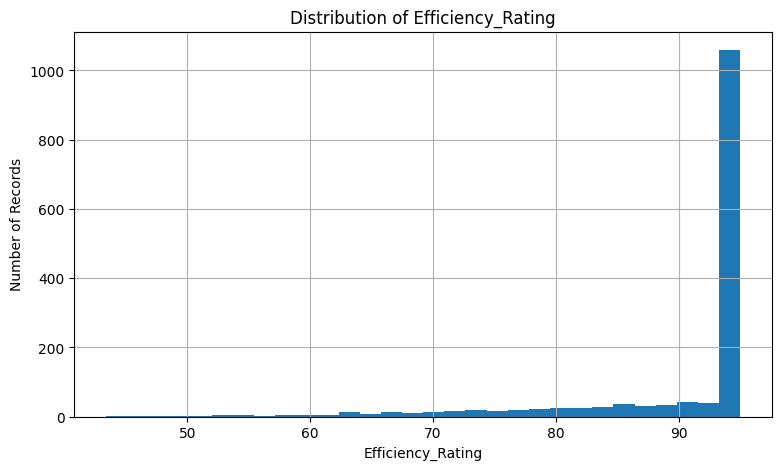

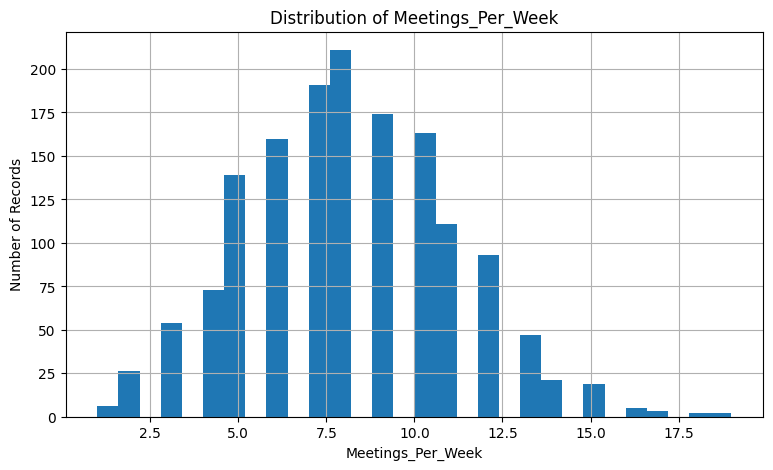

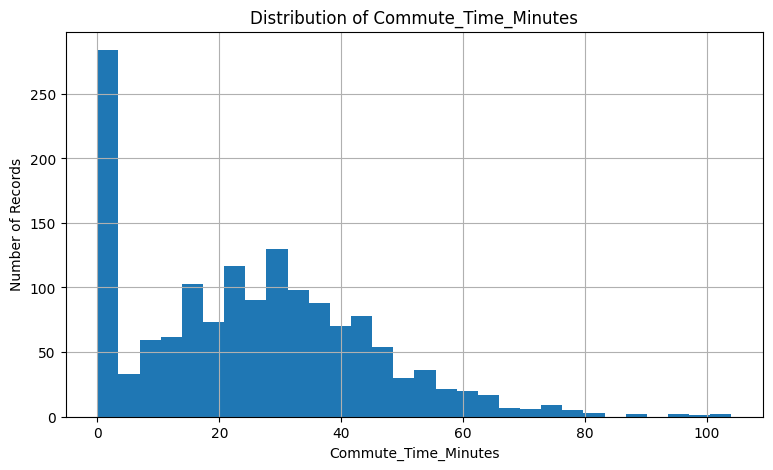

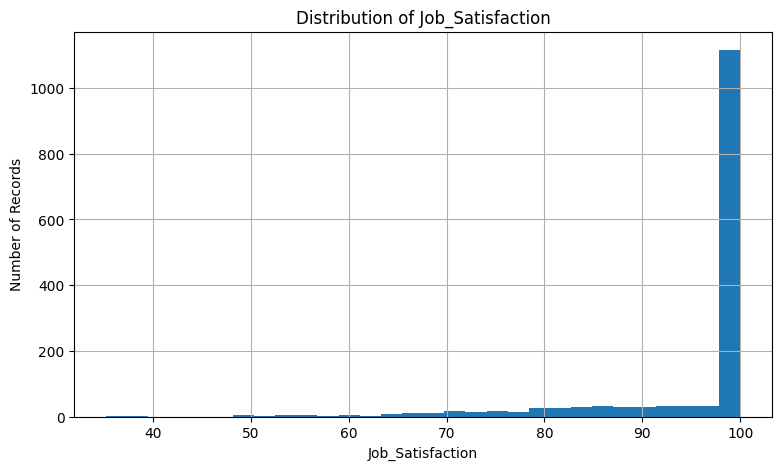

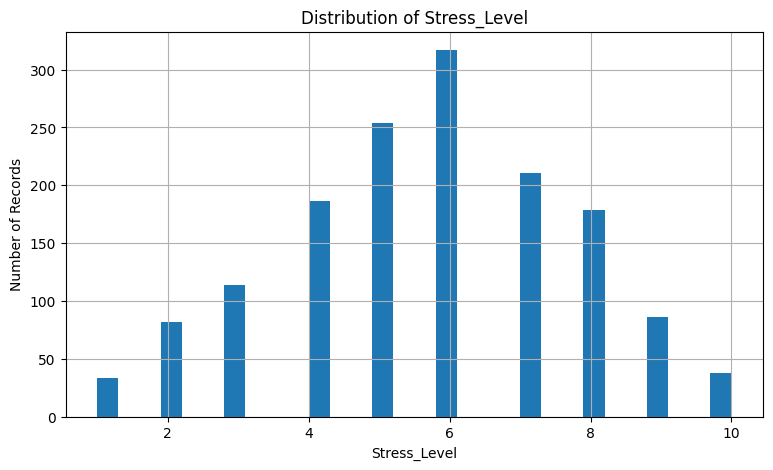

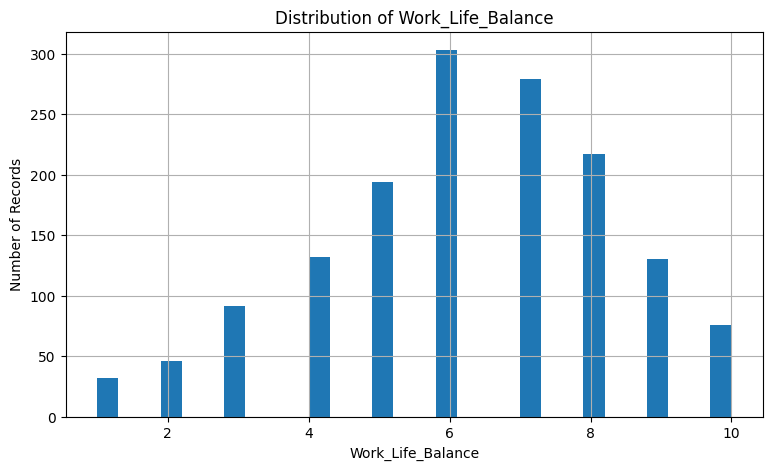

In [28]:
numeric_cols = remote_df.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns:")
print(numeric_cols)

for col in numeric_cols:
    plt.figure()
    plt.hist(remote_df[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Records")
    plt.show()

>### 💡 Insight Summary
>
>Numerical variables such as work hours, meeting frequency, and stress levels show a wide range of values across individuals. This indicates that employees operate under significantly different working conditions.
>
>The variability across these features suggests that productivity is influenced by multiple interacting factors rather than a single input. This reinforces the need for a modeling approach that can capture these combined effects.

---

## 3.3 Outlier Review

Box plots are used to flag potential outliers. These observations are not automatically removed because they may represent valid workplace patterns.

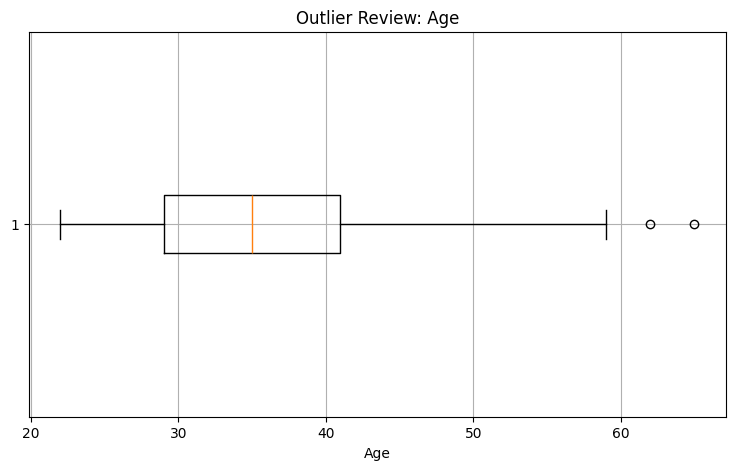

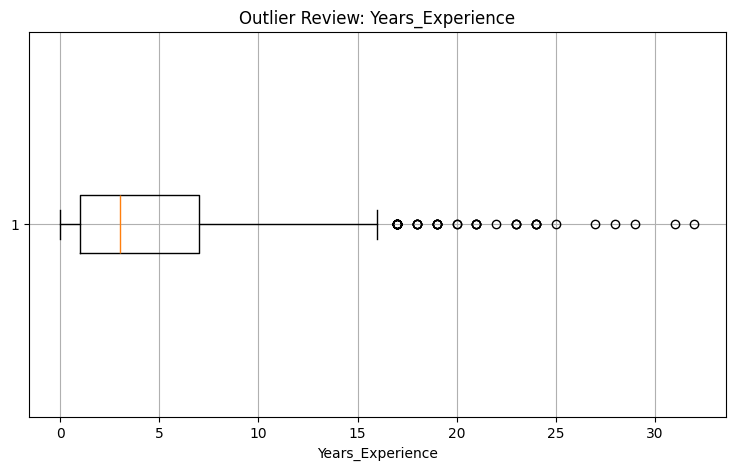

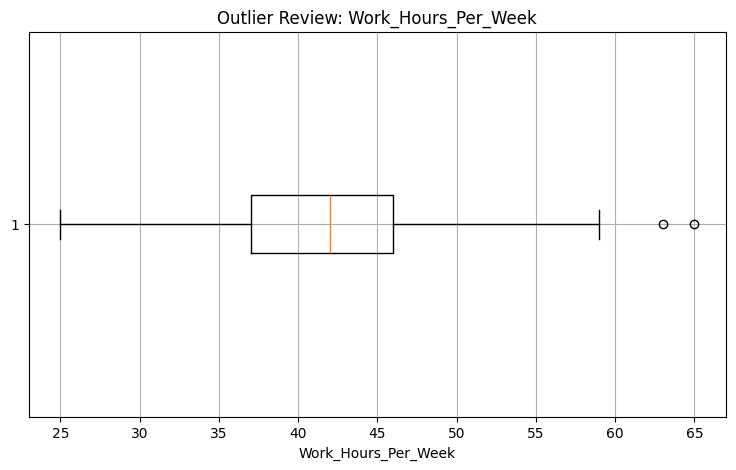

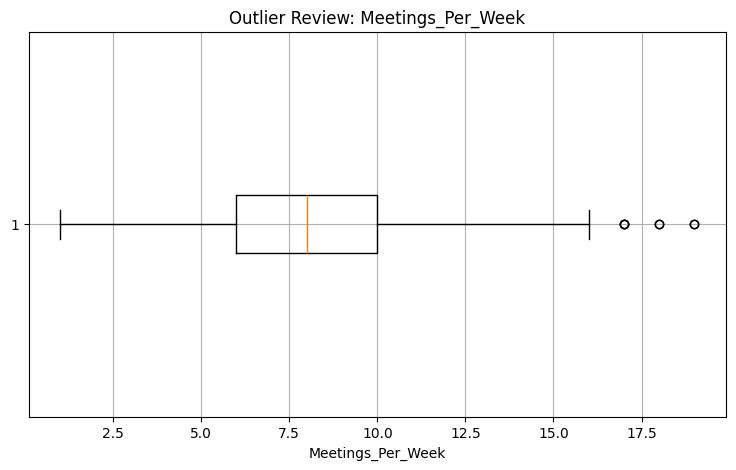

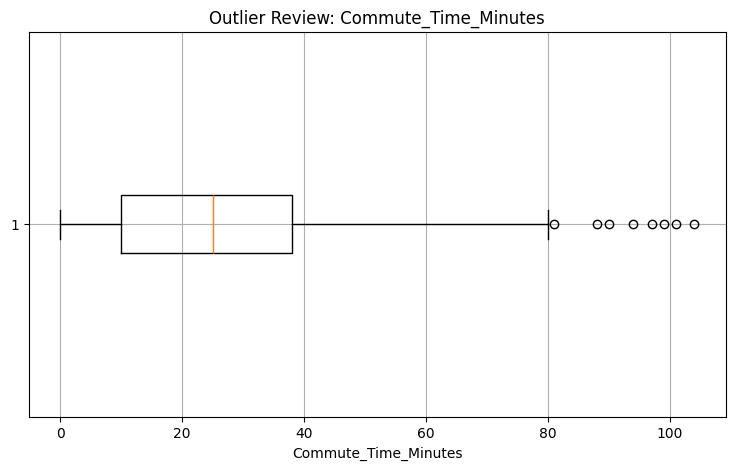

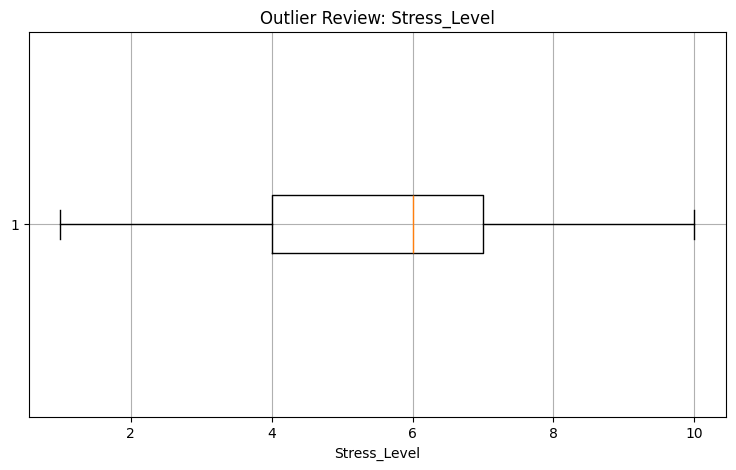

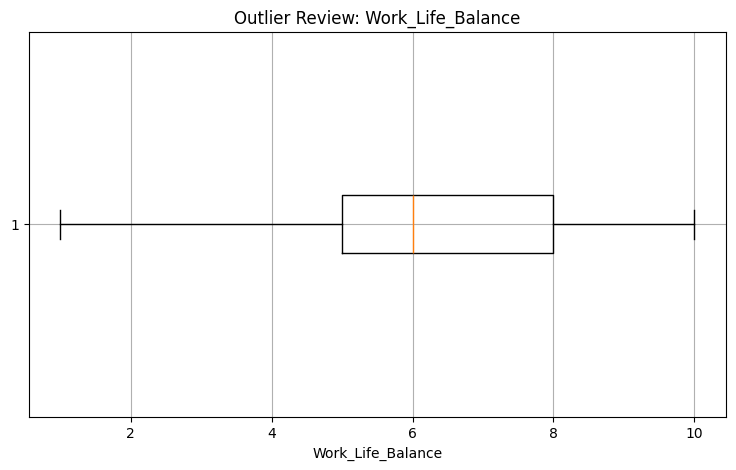

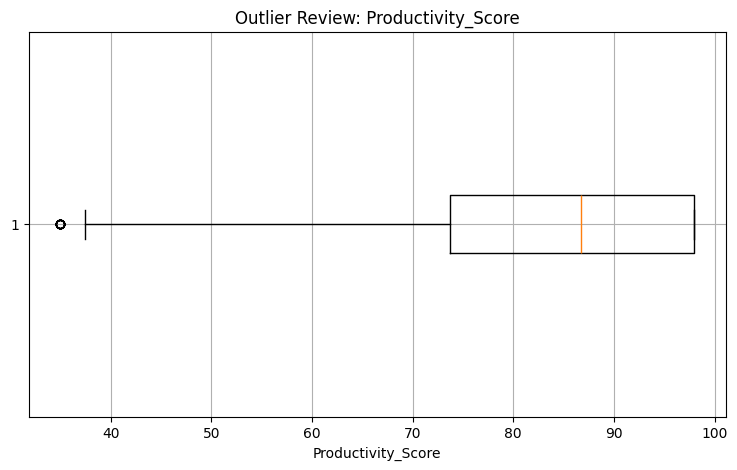

In [29]:
key_outlier_cols = [
    "Age",
    "Years_Experience",
    "Work_Hours_Per_Week",
    "Meetings_Per_Week",
    "Commute_Time_Minutes",
    "Stress_Level",
    "Work_Life_Balance",
    "Productivity_Score"
]

key_outlier_cols = [col for col in key_outlier_cols if col in remote_df.columns]

for col in key_outlier_cols:
    plt.figure()
    plt.boxplot(remote_df[col].dropna(), vert=False)
    plt.title(f"Outlier Review: {col}")
    plt.xlabel(col)
    plt.show()

>### 💡 Insight Summary
>
>Outliers are present in several variables, particularly in work hours and meeting frequency. These values likely represent real-world scenarios where individuals are experiencing unusually high workloads.
>
>Rather than being treated as errors, these observations provide insight into extreme work conditions that may contribute to reduced productivity due to overload or cognitive strain.
>
>These cases are especially relevant for identifying points where increased activity begins to reduce effectiveness.

---

## 3.4 Categorical Feature Profiles

Categorical variables provide context about worker role, environment, and organizational structure. These variables will be encoded later using the preprocessing pipeline.

Categorical columns:
['Employee_ID', 'Gender', 'Education_Level', 'Marital_Status', 'Has_Children', 'Location_Type', 'Department', 'Job_Level', 'Company_Size', 'Industry', 'Home_Office_Quality', 'Internet_Speed_Category', 'Manager_Support_Level', 'Team_Collaboration_Frequency', 'Survey_Date', 'Response_Quality']

Employee_ID


,count
Employee_ID,
EMP0001,1
EMP0998,1
EMP1007,1
EMP1006,1
EMP1005,1
...,...
EMP0498,1
EMP0497,1
EMP0496,1


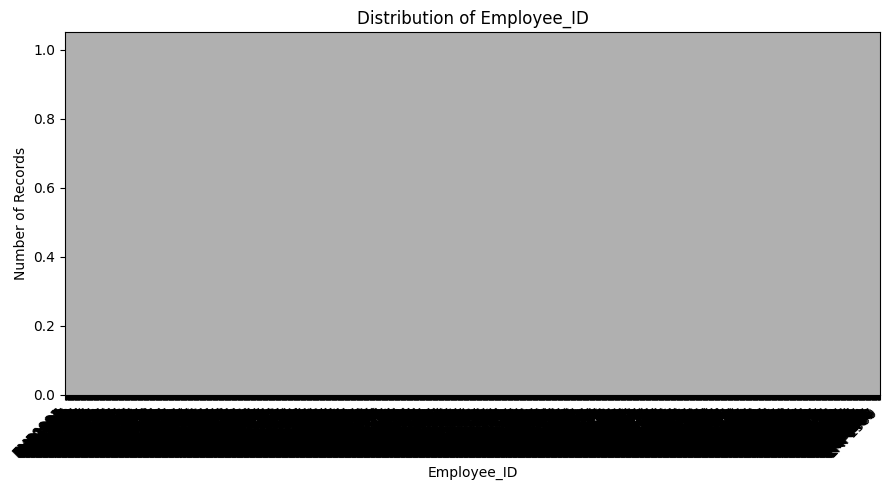


Gender


,count
Gender,
Female,737
Male,703
Non-binary,60


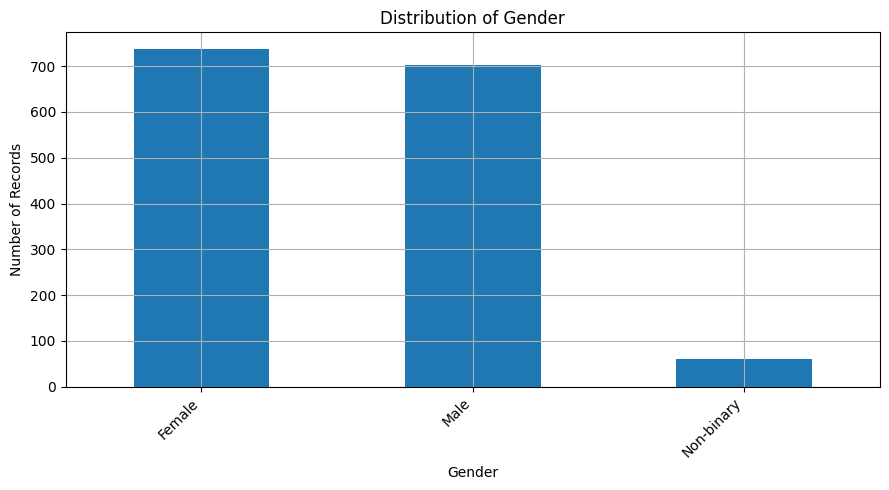


Education_Level


,count
Education_Level,
Bachelor Degree,673
Master Degree,489
Associate Degree,153
PhD,88
High School,72
Professional Degree,25


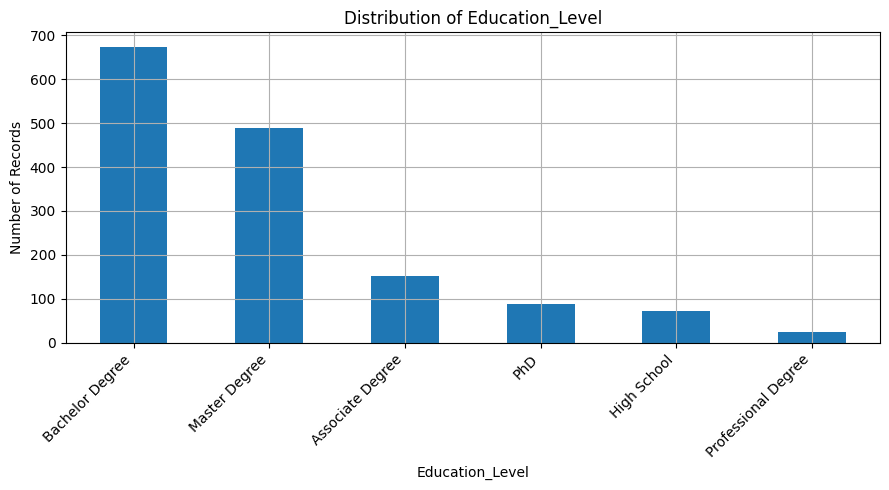


Marital_Status


,count
Marital_Status,
Married,775
Single,417
Divorced,186
In Relationship,122


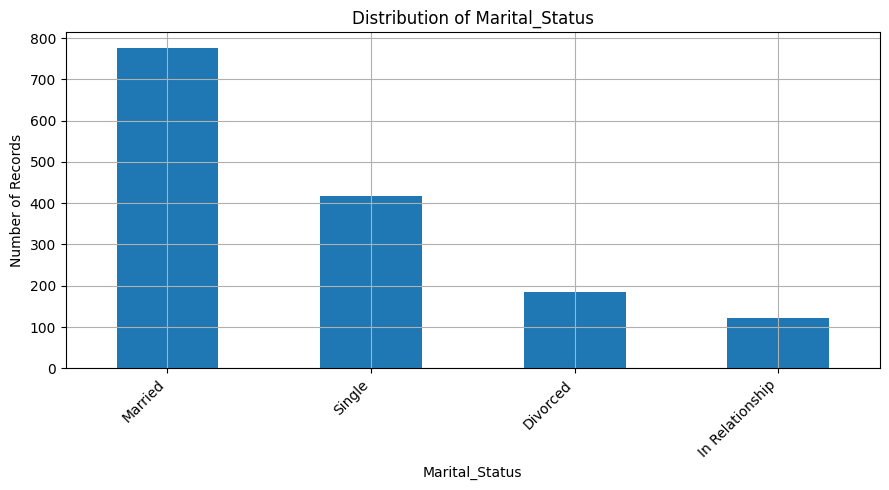


Has_Children


,count
Has_Children,
No,824
Yes,676


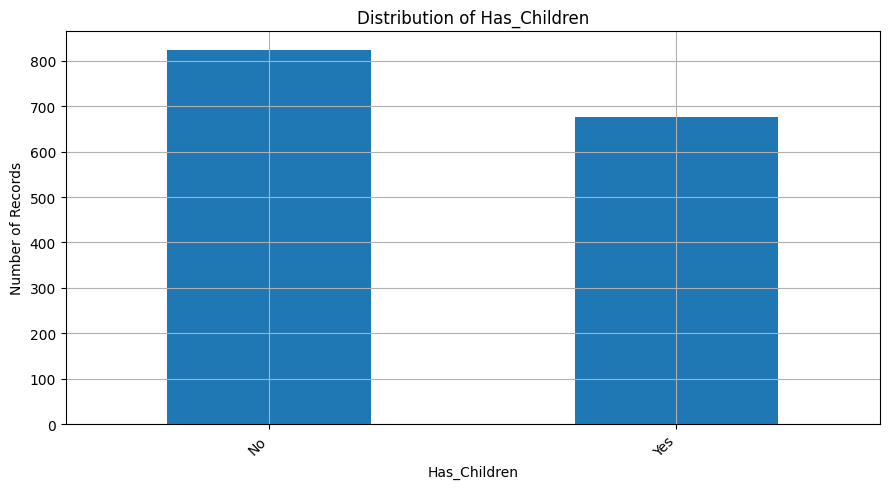


Location_Type


,count
Location_Type,
Suburban,672
Urban,664
Rural,164


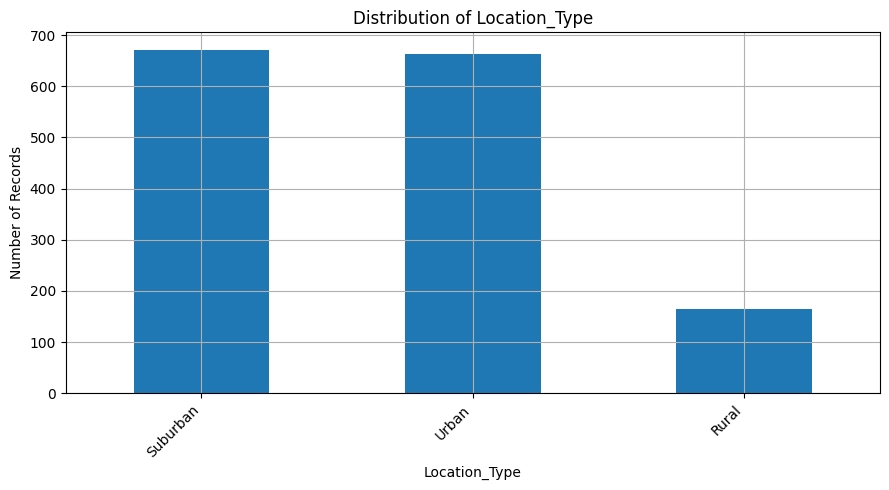


Department


,count
Department,
Engineering,455
Sales,202
Marketing,176
Operations,137
Customer Success,120
Finance,112
HR,101
Product,81
Design,60


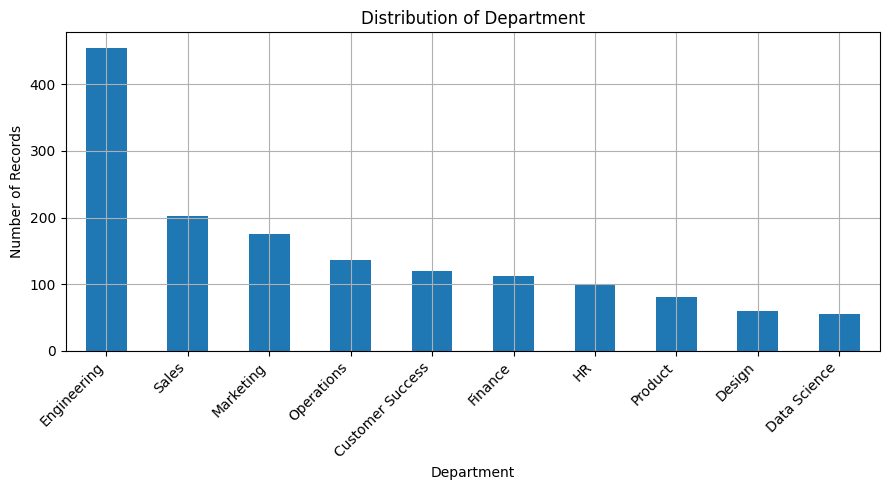


Job_Level


,count
Job_Level,
Junior,539
Mid-Level,422
Senior,322
Lead,149
Manager,61
Director,7


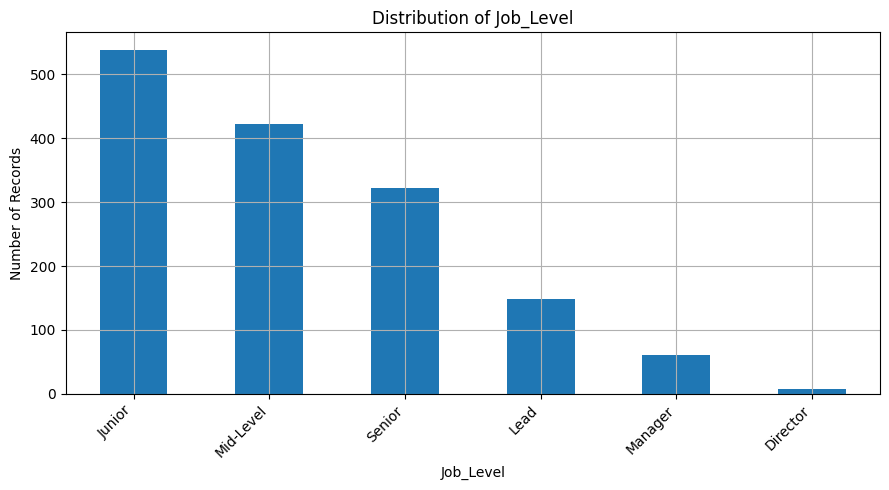


Company_Size


,count
Company_Size,
Large (1001-5000),386
Medium (201-1000),384
Small (51-200),352
Startup (1-50),225
Enterprise (5000+),153


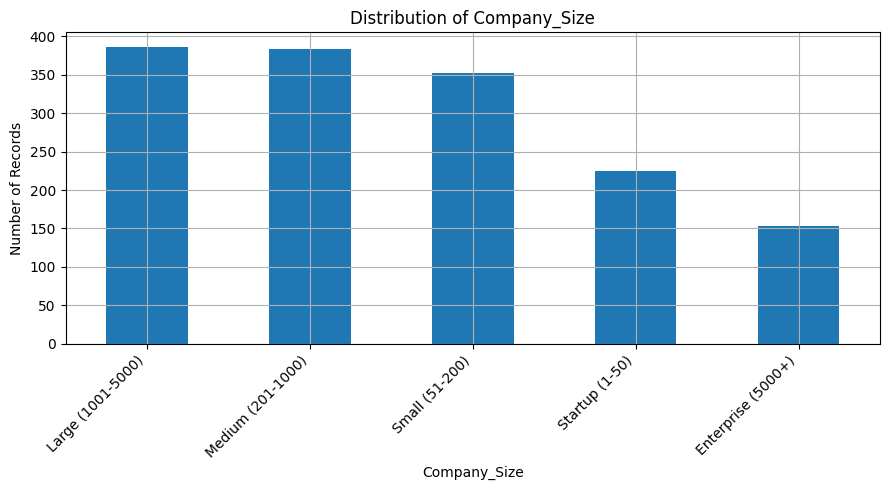


Industry


,count
Industry,
Technology,475
Finance,223
Healthcare,185
Education,144
Retail,106
Manufacturing,93
Consulting,88
Government,74
Media,72


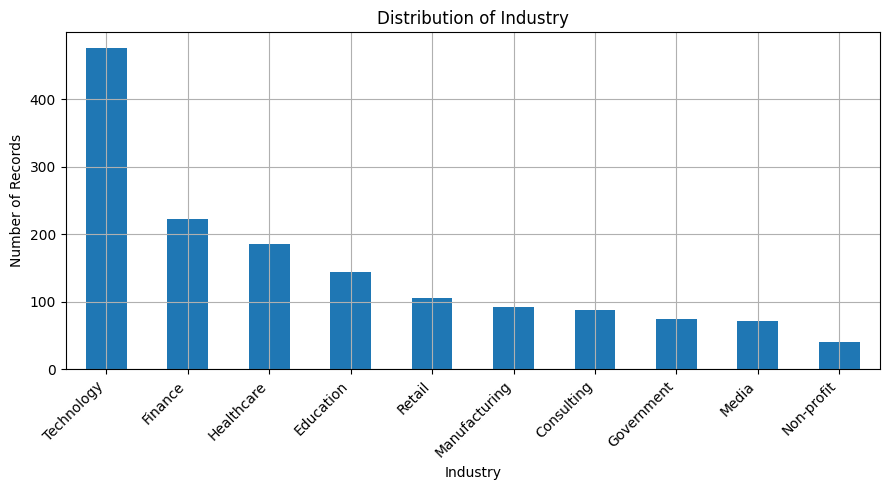


Home_Office_Quality


,count
Home_Office_Quality,
Good,595
Average,452
Excellent,340
Poor,113


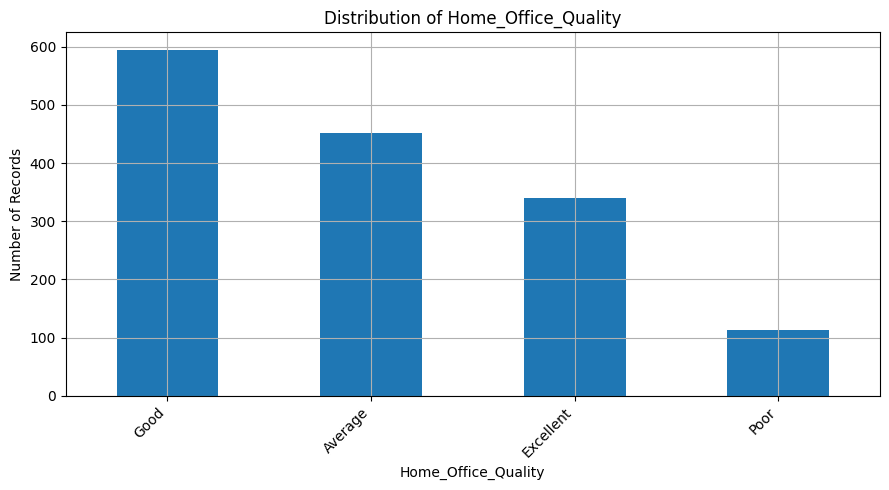


Internet_Speed_Category


,count
Internet_Speed_Category,
Very Fast (100+ Mbps),691
Fast (50-100 Mbps),505
Moderate (25-50 Mbps),231
Slow (<25 Mbps),73


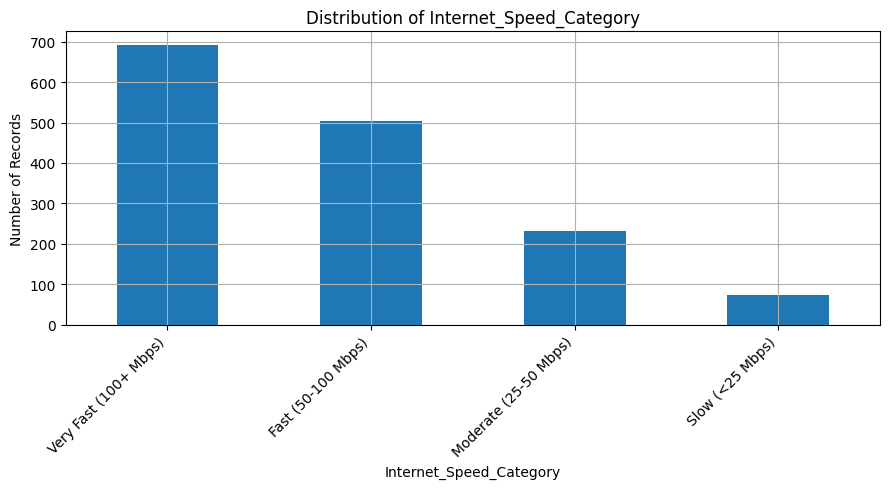


Manager_Support_Level


,count
Manager_Support_Level,
Moderate,542
High,492
Very High,253
Low,174
Very Low,39


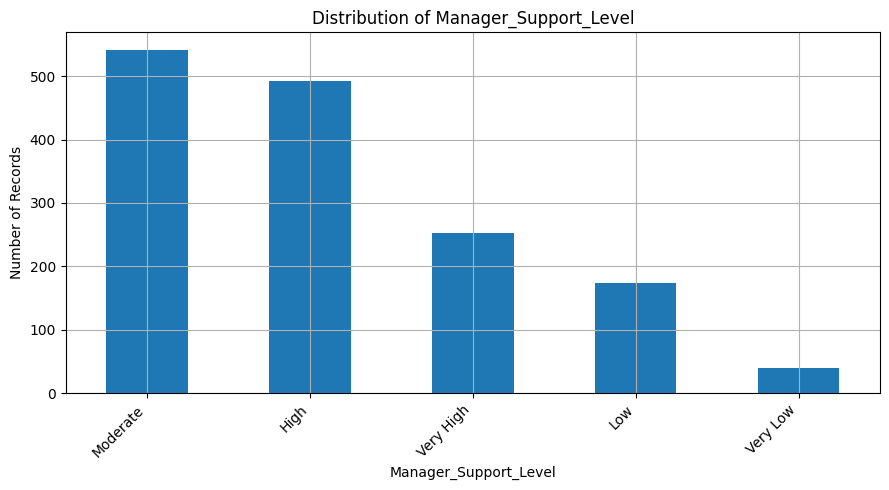


Team_Collaboration_Frequency


,count
Team_Collaboration_Frequency,
Daily,510
Few times per week,445
Weekly,340
Bi-weekly,131
Monthly,74


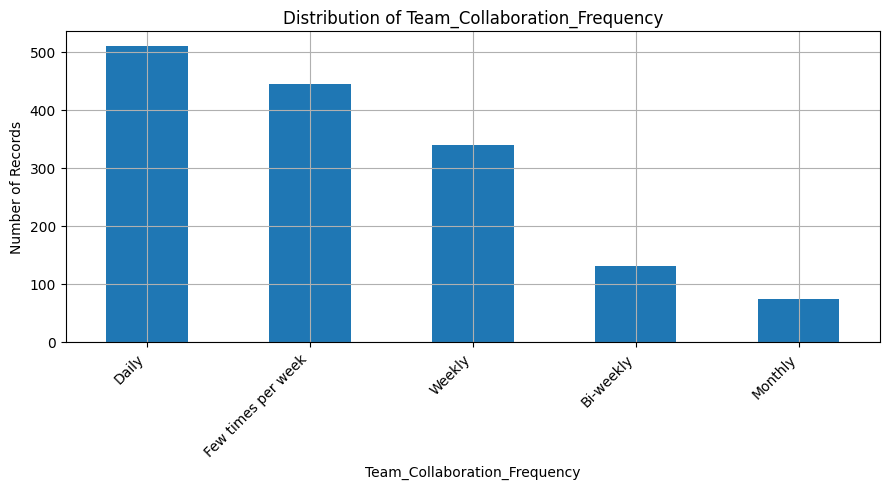


Survey_Date


,count
Survey_Date,
2024-05-04,22
2024-02-15,21
2024-03-25,20
2024-02-17,19
2024-02-19,18
...,...
2024-02-07,7
2024-03-16,7
2024-04-02,7


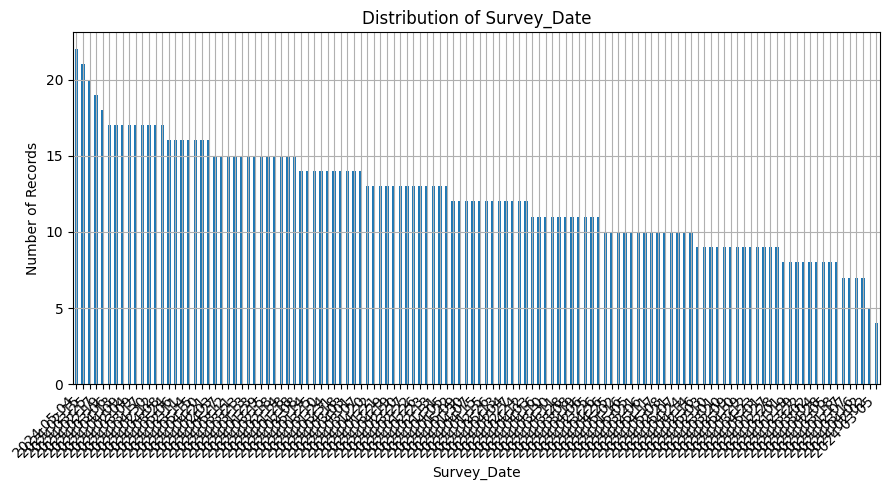


Response_Quality


,count
Response_Quality,
High,1053
Medium,367
Low,80


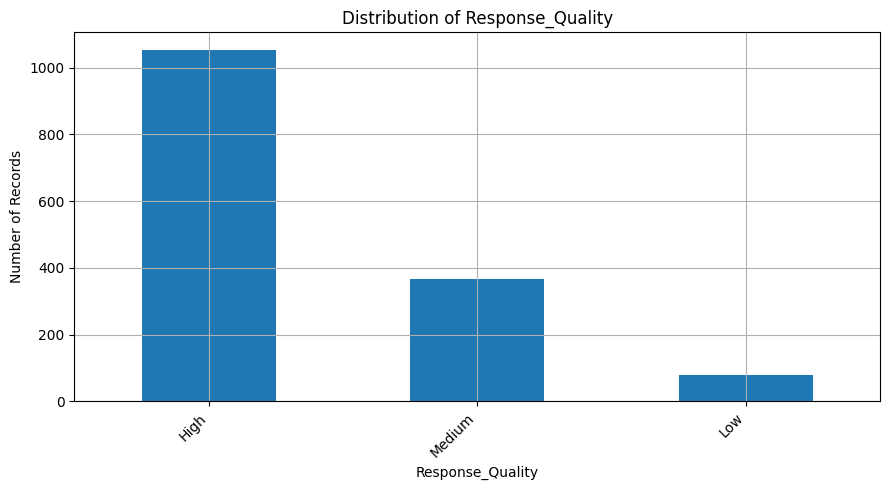

In [30]:
categorical_cols = remote_df.select_dtypes(exclude=np.number).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

for col in categorical_cols:
    print(f"\n{col}")
    display(remote_df[col].value_counts(dropna=False).to_frame("count"))

    counts = remote_df[col].value_counts(dropna=False)
    plt.figure()
    counts.plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Records")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

>### 💡 Insight Summary
>
>Categorical variables reveal differences in how work is structured across departments, job levels, and work environments. These differences suggest that productivity is influenced by both individual behavior and organizational context.
>
>This highlights the importance of including contextual variables in the model, as productivity cannot be fully explained by activity-based measures alone.

---

## 3.5 Correlation Analysis

Correlation analysis provides an initial view of linear relationships between numerical variables. This helps identify candidate predictors and potential multicollinearity risks.

,Age,Years_Experience,WFH_Days_Per_Week,Work_Hours_Per_Week,Productivity_Score,Task_Completion_Rate,Quality_Score,Innovation_Score,Efficiency_Rating,Meetings_Per_Week,Commute_Time_Minutes,Job_Satisfaction,Stress_Level,Work_Life_Balance
Age,1.000,0.664,0.017,-0.022,0.266,0.244,0.259,0.181,0.239,0.039,-0.030,0.136,-0.013,-0.035
Years_Experience,0.664,1.000,-0.004,0.008,0.253,0.218,0.258,0.248,0.212,0.040,0.004,0.139,-0.019,-0.035
WFH_Days_Per_Week,0.017,-0.004,1.000,0.004,0.018,0.043,0.023,0.008,0.013,-0.028,-0.437,-0.001,-0.020,-0.034
Work_Hours_Per_Week,-0.022,0.008,0.004,1.000,-0.031,-0.018,-0.037,-0.008,-0.093,0.016,0.024,-0.039,-0.007,0.041
Productivity_Score,0.266,0.253,0.018,-0.031,1.000,0.884,0.918,0.783,0.838,-0.004,-0.031,0.513,-0.015,0.030
Task_Completion_Rate,0.244,0.218,0.043,-0.018,0.884,1.000,0.811,0.686,0.733,0.017,-0.052,0.444,-0.031,0.024
Quality_Score,0.259,0.258,0.023,-0.037,0.918,0.811,1.000,0.734,0.772,-0.007,-0.037,0.472,0.002,0.028
Innovation_Score,0.181,0.248,0.008,-0.008,0.783,0.686,0.734,1.000,0.653,-0.000,-0.049,0.443,0.001,0.023
Efficiency_Rating,0.239,0.212,0.013,-0.093,0.838,0.733,0.772,0.653,1.000,-0.012,-0.034,0.489,-0.014,0.025
Meetings_Per_Week,0.039,0.040,-0.028,0.016,-0.004,0.017,-0.007,-0.000,-0.012,1.000,0.023,0.006,-0.021,0.032


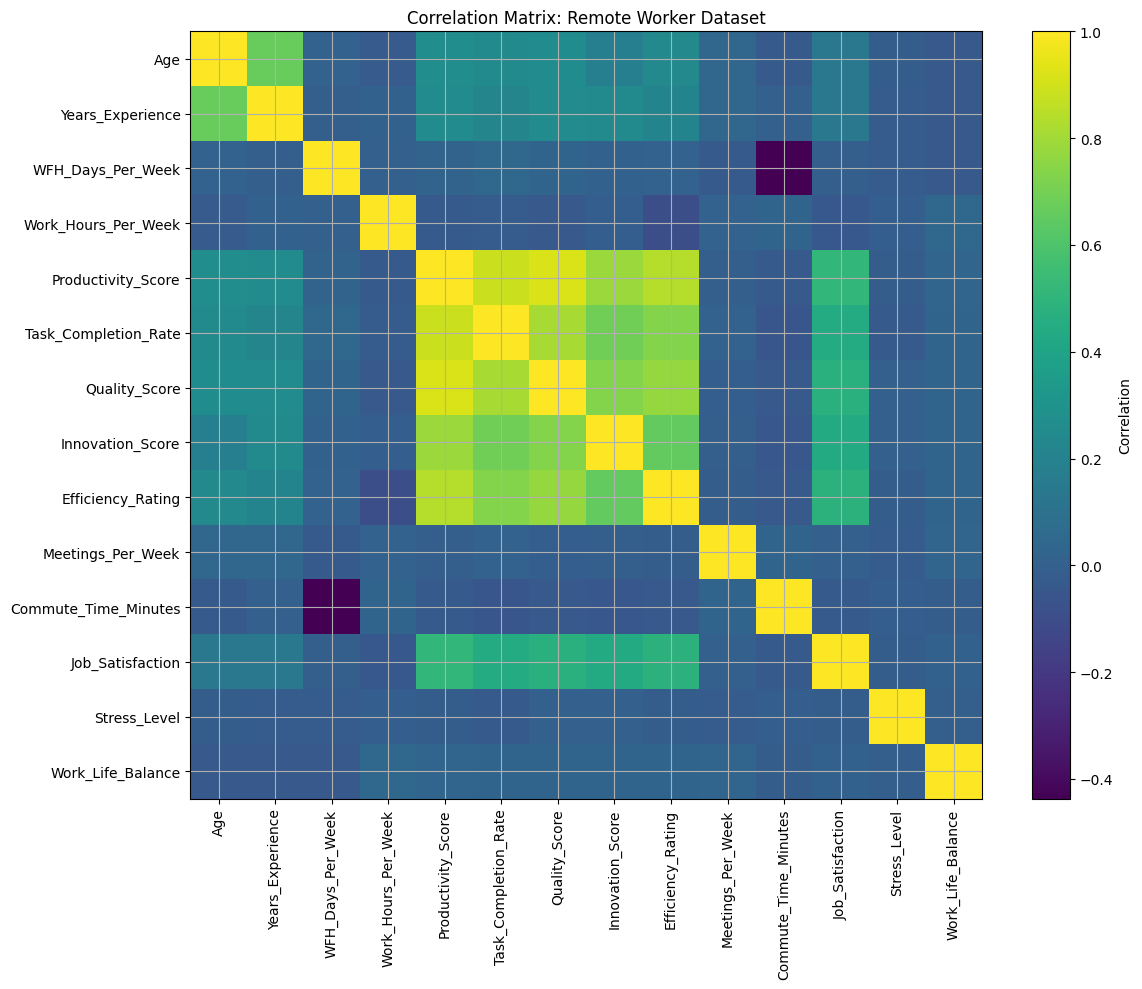

Strongest numerical correlations with Productivity_Score:


,correlation
Quality_Score,0.918
Task_Completion_Rate,0.884
Efficiency_Rating,0.838
Innovation_Score,0.783
Job_Satisfaction,0.513
Age,0.266
Years_Experience,0.253
Commute_Time_Minutes,-0.031
Work_Hours_Per_Week,-0.031
Work_Life_Balance,0.030


In [31]:
corr = remote_df.select_dtypes(include=np.number).corr()

display(corr.round(3))

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix: Remote Worker Dataset")
plt.tight_layout()
plt.show()

target_corr = corr[target].drop(target).sort_values(key=lambda s: s.abs(), ascending=False)
print("Strongest numerical correlations with Productivity_Score:")
display(target_corr.to_frame("correlation").round(3))

>### 💡 Insight Summary
>
>The correlation analysis shows that no single variable strongly predicts productivity on its own. Instead, multiple variables exhibit moderate relationships with `Productivity_Score`.
>
>This indicates that productivity is driven by a combination of factors rather than a single dominant variable. It also suggests that linear relationships alone may not fully capture the underlying patterns, supporting the use of more flexible machine learning models.

## 3.6 Relationships with the Target Variable

Scatter plots show how key numerical features relate to `Productivity_Score`. These visuals support hypothesis generation but do not establish causality.

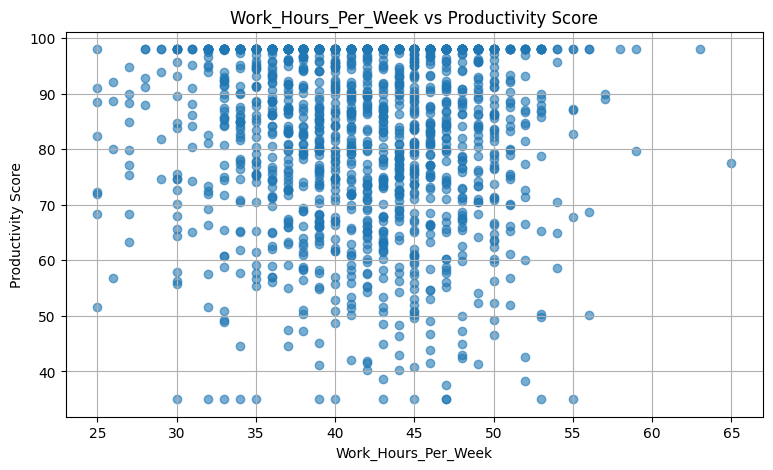

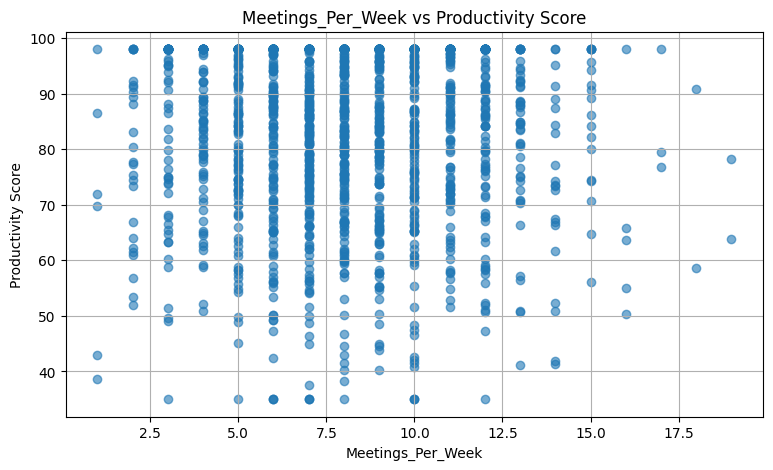

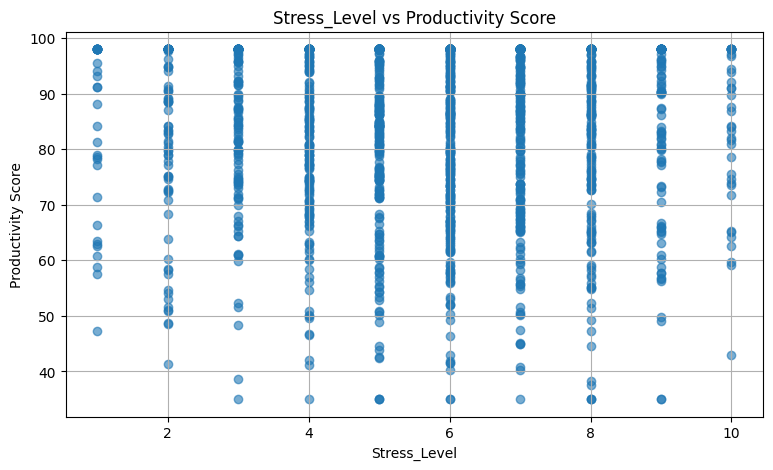

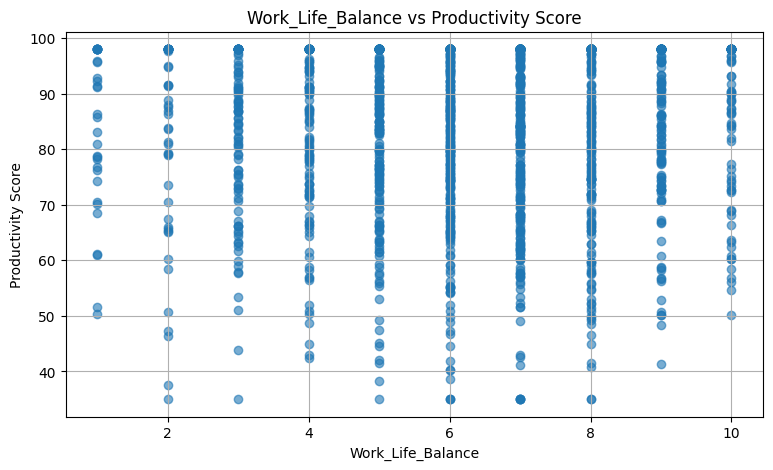

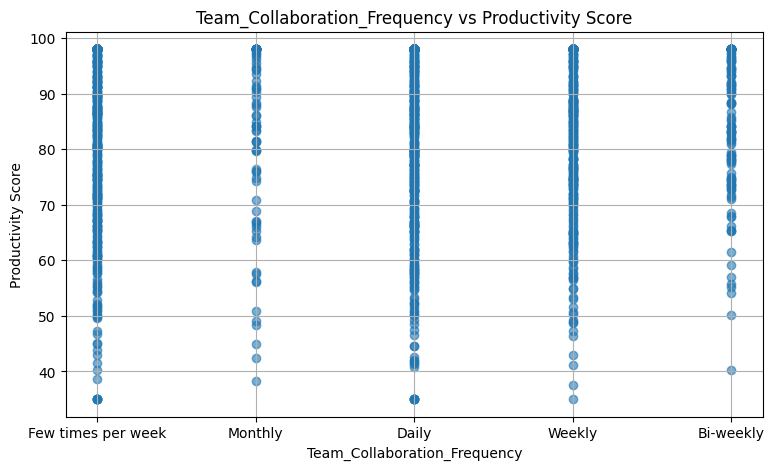

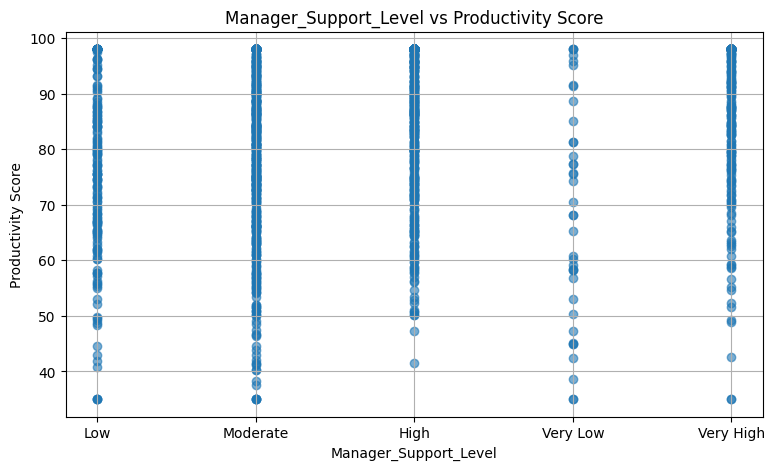

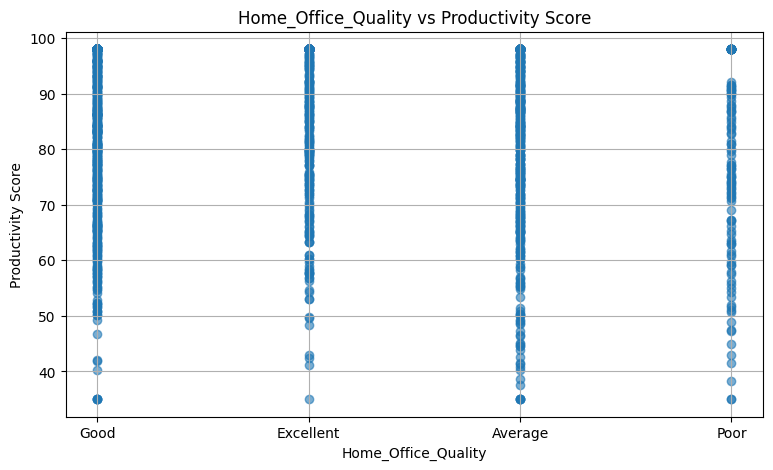

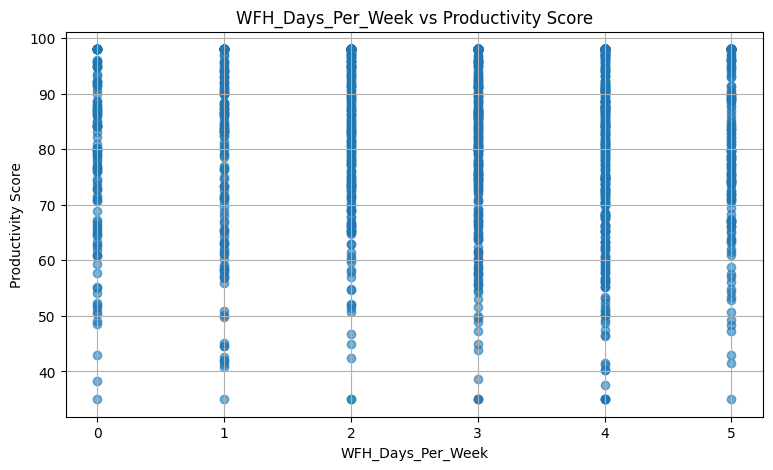

In [32]:
target_relationship_cols = [
    "Work_Hours_Per_Week",
    "Meetings_Per_Week",
    "Stress_Level",
    "Work_Life_Balance",
    "Team_Collaboration_Frequency",
    "Manager_Support_Level",
    "Home_Office_Quality",
    "WFH_Days_Per_Week"
]

target_relationship_cols = [col for col in target_relationship_cols if col in remote_df.columns]

for col in target_relationship_cols:
    plt.figure()
    plt.scatter(remote_df[col], remote_df[target], alpha=0.6)
    plt.title(f"{col} vs Productivity Score")
    plt.xlabel(col)
    plt.ylabel("Productivity Score")
    plt.show()

>### 💡 Insight Summary
>
>The relationships between individual variables and productivity are not strictly linear. Increases in work hours or meeting frequency do not consistently lead to higher productivity.
>
>In some cases, productivity appears to plateau or decline as these variables increase, suggesting diminishing returns. This supports the idea that excessive workload or interruptions can reduce overall effectiveness.

## 3.7 Average Productivity by Categorical Group

Grouped comparisons help identify whether productivity differs across departments, job levels, industries, or work contexts.


Productivity by Department:


,count,mean,median,std
Department,,,,
Design,60,85.78,88.15,12.57
Engineering,455,85.30,88.90,13.90
Marketing,176,83.56,88.90,15.66
Finance,112,83.22,86.55,15.19
HR,101,83.14,86.50,15.55
Data Science,56,82.91,85.95,17.19
Operations,137,81.61,86.20,15.61
Product,81,81.00,85.80,16.10
Sales,202,80.65,83.90,16.83


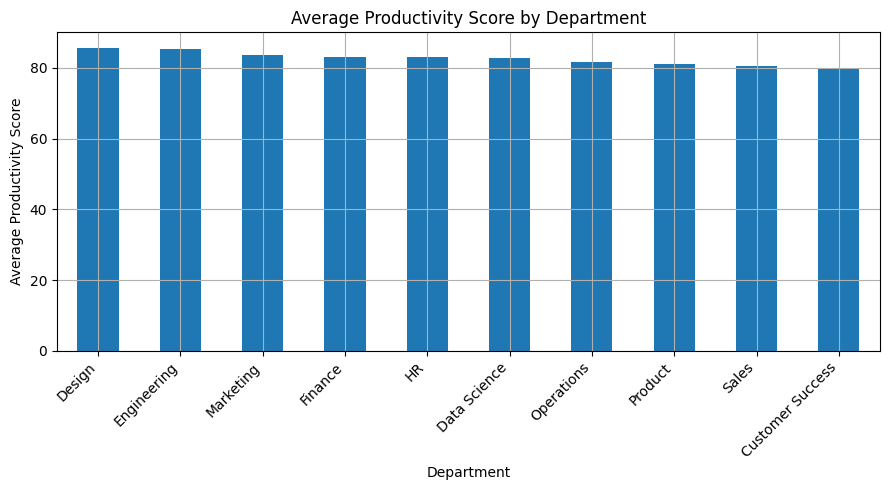


Productivity by Job_Level:


,count,mean,median,std
Job_Level,,,,
Manager,61,90.31,95.30,9.81
Senior,322,88.12,93.50,11.75
Lead,149,86.65,91.50,13.82
Director,7,85.70,84.20,6.39
Mid-Level,422,82.67,86.75,15.30
Junior,539,78.59,80.30,16.48


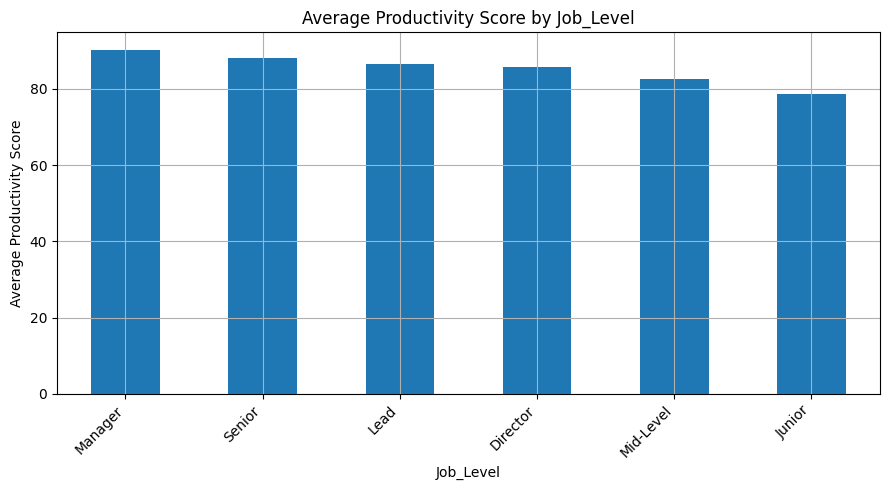


Productivity by Company_Size:


,count,mean,median,std
Company_Size,,,,
Large (1001-5000),386,83.66,87.95,15.02
Enterprise (5000+),153,83.62,88.40,15.83
Small (51-200),352,83.61,87.30,15.05
Startup (1-50),225,83.18,85.80,14.61
Medium (201-1000),384,81.80,84.30,15.69


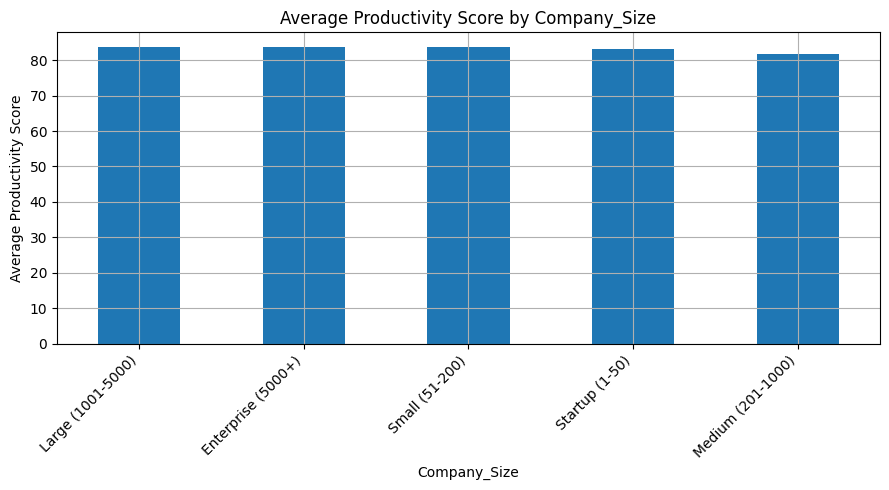


Productivity by Industry:


,count,mean,median,std
Industry,,,,
Healthcare,185,84.86,88.30,14.27
Retail,106,84.24,86.60,12.86
Finance,223,83.89,87.50,14.60
Manufacturing,93,83.45,86.30,15.45
Consulting,88,83.36,84.60,14.31
Media,72,83.04,87.75,14.48
Technology,475,82.73,87.10,16.18
Education,144,82.48,85.85,16.00
Non-profit,40,80.33,84.10,16.88


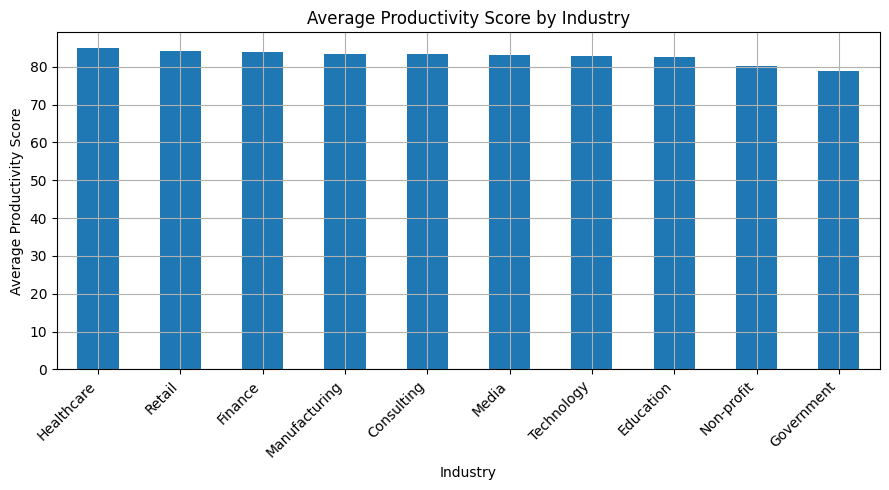


Productivity by Location_Type:


,count,mean,median,std
Location_Type,,,,
Suburban,672,83.60,86.60,14.52
Rural,164,83.55,87.40,14.57
Urban,664,82.47,86.45,16.06


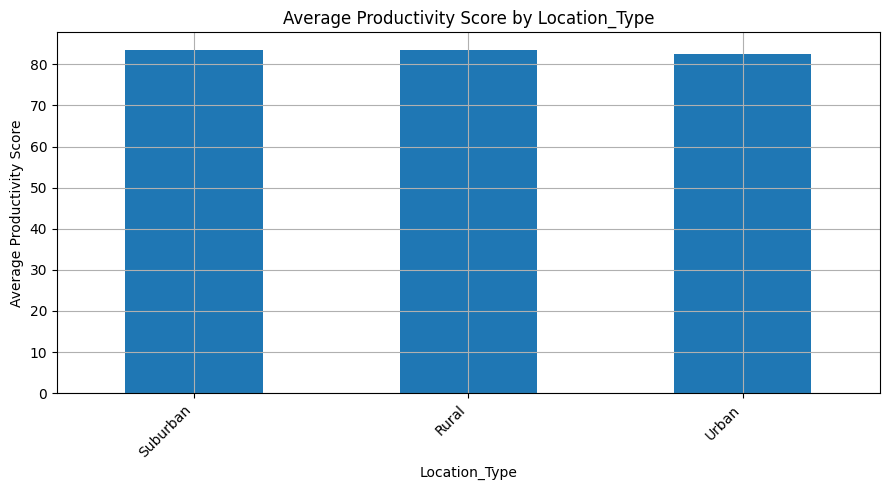


Productivity by Education_Level:


,count,mean,median,std
Education_Level,,,,
PhD,88,84.08,88.15,14.13
Bachelor Degree,673,84.02,87.70,14.96
Associate Degree,153,82.95,87.30,15.40
High School,72,82.54,88.50,17.09
Master Degree,489,82.00,84.20,15.27
Professional Degree,25,78.50,82.50,17.62


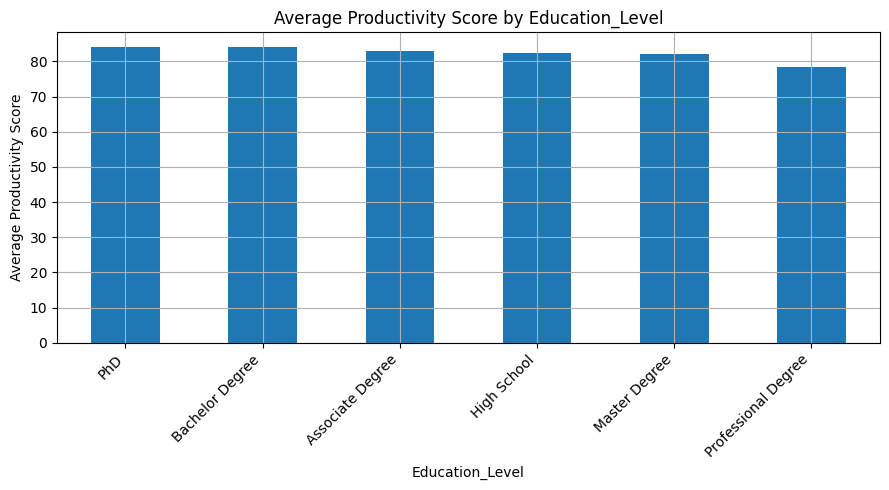

In [33]:
group_cols = ["Department", "Job_Level", "Company_Size", "Industry", "Location_Type", "Education_Level"]
group_cols = [col for col in group_cols if col in remote_df.columns]

for col in group_cols:
    grouped = (
        remote_df.groupby(col)[target]
        .agg(["count", "mean", "median", "std"])
        .sort_values("mean", ascending=False)
        .round(2)
    )

    print(f"\nProductivity by {col}:")
    display(grouped)

    plt.figure()
    grouped["mean"].plot(kind="bar")
    plt.title(f"Average Productivity Score by {col}")
    plt.xlabel(col)
    plt.ylabel("Average Productivity Score")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

>### 💡 Insight Summary
>
>Productivity varies across different groups, including department, job level, and work environment. These differences indicate that structural and organizational factors play a role in performance outcomes.
>
>This reinforces the importance of considering both individual work patterns and broader context when analyzing productivity.

---

## 3.8 Focus and Distraction Dataset Context

The Focus and Distraction dataset is reviewed to understand behavioral patterns related to attention, interruption, and cognitive load. It is not directly merged with the Remote Worker dataset because there are no shared identifiers.


focus_duration_single_task


,count
focus_duration_single_task,
more_than_30_minutes,307
11_20_minutes,199
21_30_minutes,187
5_10_minutes,83
less_than_5_minutes,14


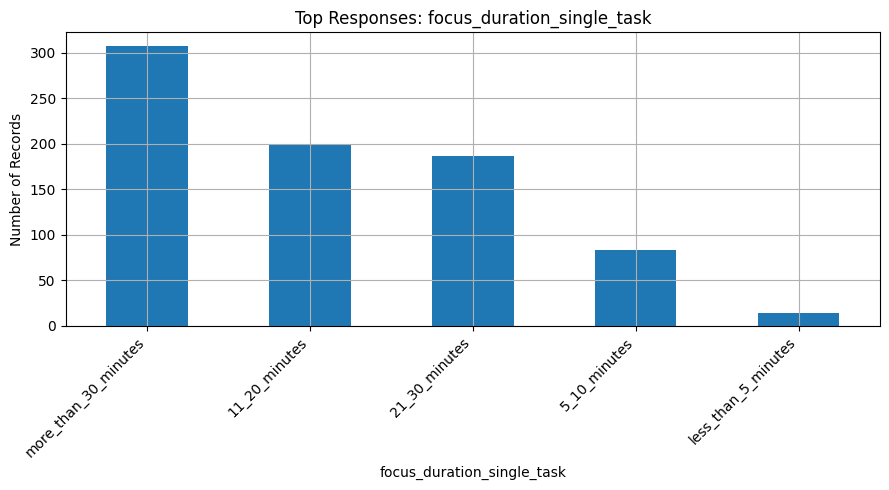


main_distractions_multi


,count
main_distractions_multi,
email_messaging_apps;smartphone_notifications;social_media_scrolling,34
email_messaging_apps;multitasking_switching_tasks;smartphone_notifications,33
colleagues_family_friends;email_messaging_apps;smartphone_notifications,31
colleagues_family_friends;multitasking_switching_tasks;smartphone_notifications,30
colleagues_family_friends;smartphone_notifications;social_media_scrolling,26
background_noise_environment;internal_thoughts_worries;multitasking_switching_tasks,24
multitasking_switching_tasks;smartphone_notifications;social_media_scrolling,24
internal_thoughts_worries;smartphone_notifications;social_media_scrolling,23
background_noise_environment;smartphone_notifications;social_media_scrolling,20


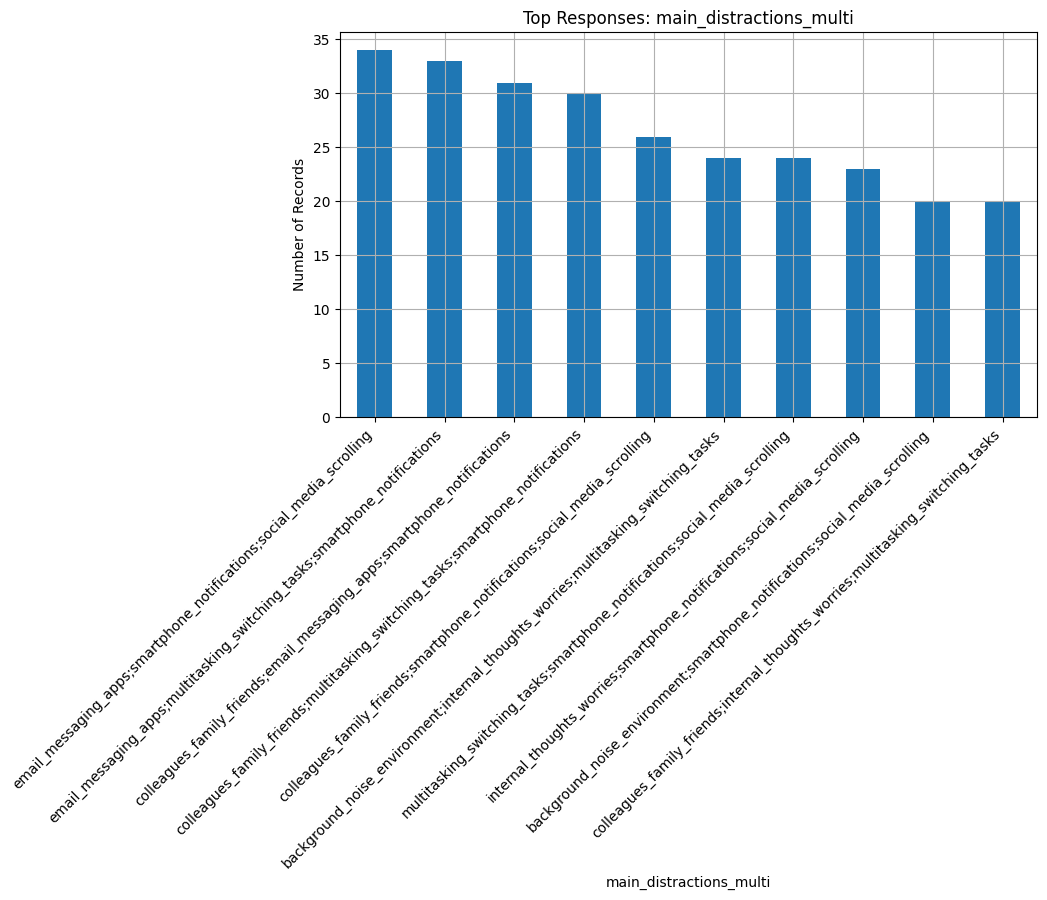


tired_even_without_hard_work


,count
tired_even_without_hard_work,
sometimes,366
rarely,235
often,133
almost_always,37
never,19


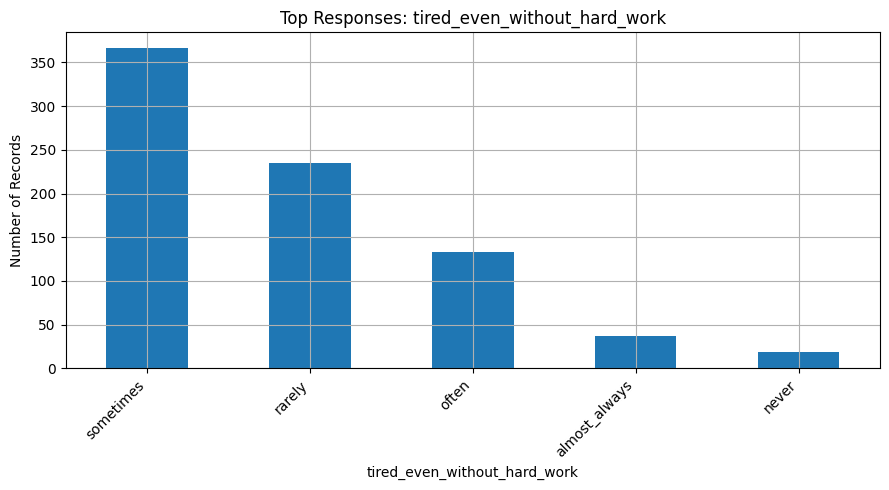


frustration_cant_stay_focused


,count
frustration_cant_stay_focused,
sometimes,329
often,206
rarely,158
almost_always,83
never,14


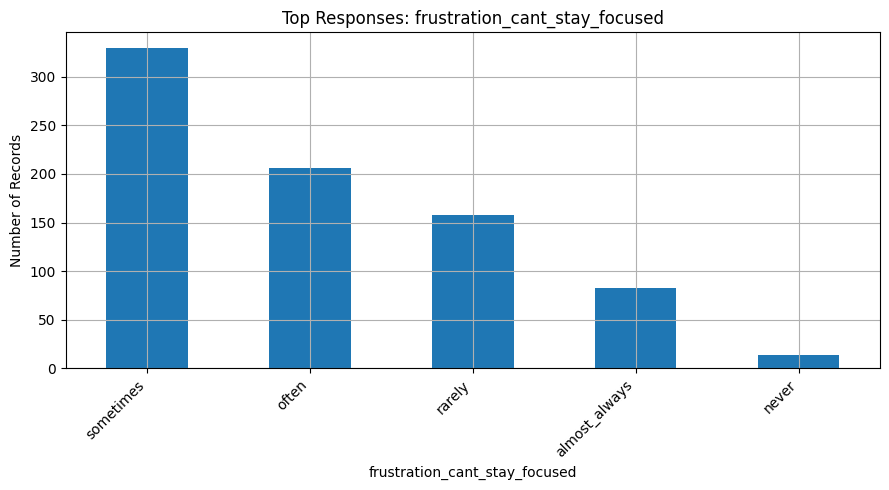


busy_all_day_accomplish_little


,count
busy_all_day_accomplish_little,
sometimes,322
rarely,213
often,192
almost_always,44
never,19


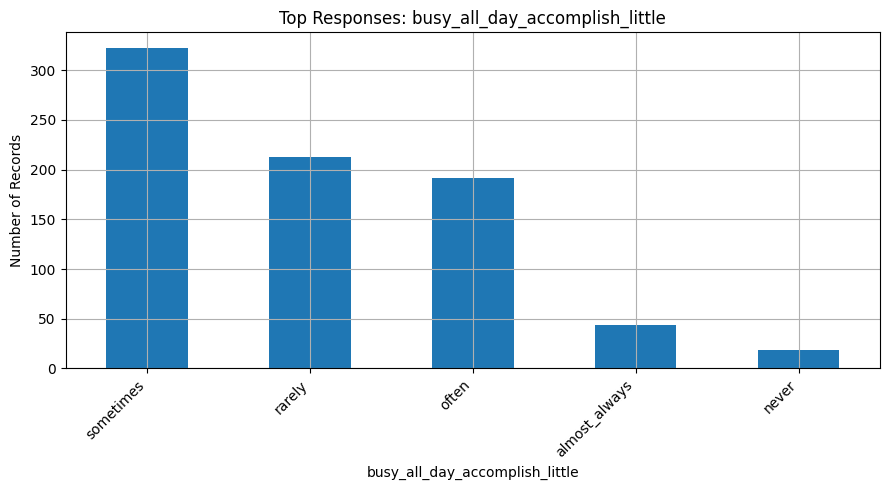


distraction_strategies_multi


,count
distraction_strategies_multi,
silencing_notifications;taking_breaks_exercise;working_in_quiet_spaces,100
taking_breaks_exercise;working_in_quiet_spaces,74
silencing_notifications;taking_breaks_exercise,58
silencing_notifications;working_in_quiet_spaces,58
aligning_tasks_with_priorities_values;taking_breaks_exercise;working_in_quiet_spaces,51
taking_breaks_exercise,45
none_of_the_above,44
working_in_quiet_spaces,44
aligning_tasks_with_priorities_values;silencing_notifications;taking_breaks_exercise;working_in_quiet_spaces,32


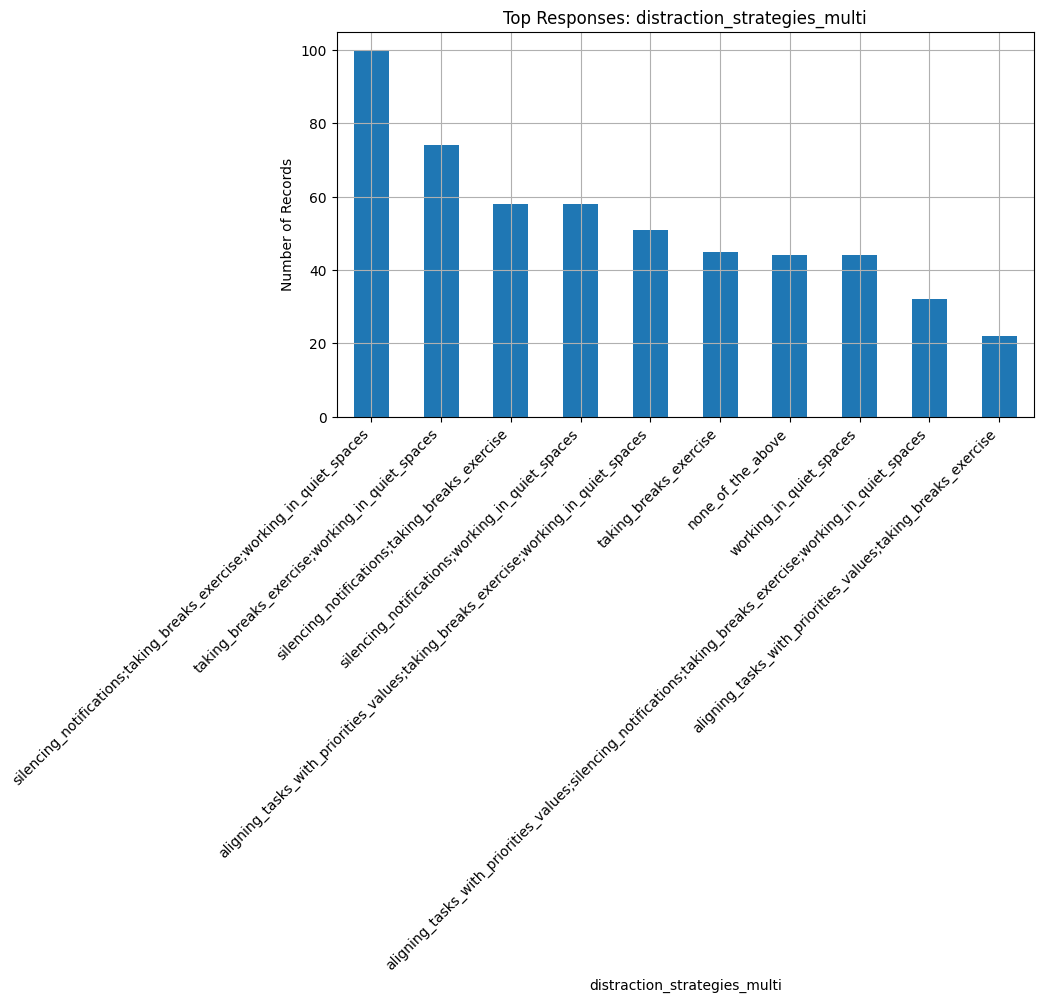


behaviour_alignment


,count
behaviour_alignment,
somewhat_aligned,418
neutral,160
very_strongly_aligned,112
somewhat_misaligned,87
not_aligned_at_all,13


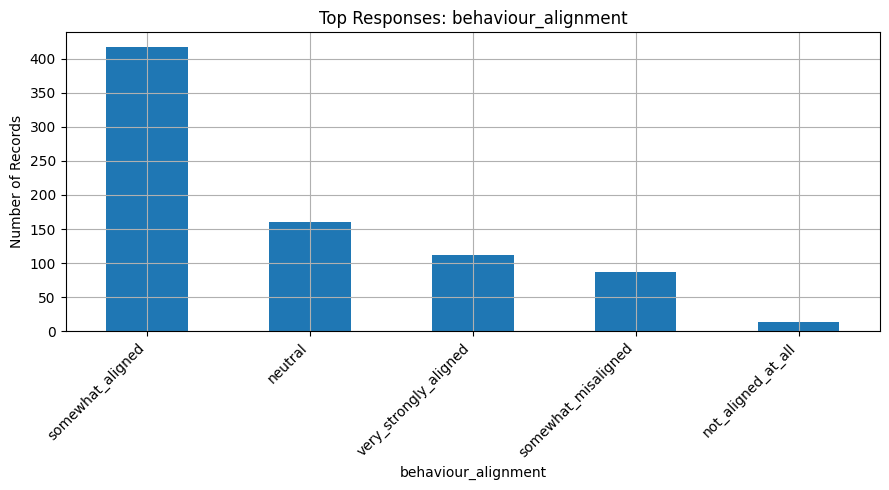


work_status


,count
work_status,
employed_full_time,413
employed_part_time,121
self_employed,100
other,74
unemployed,66
student,16


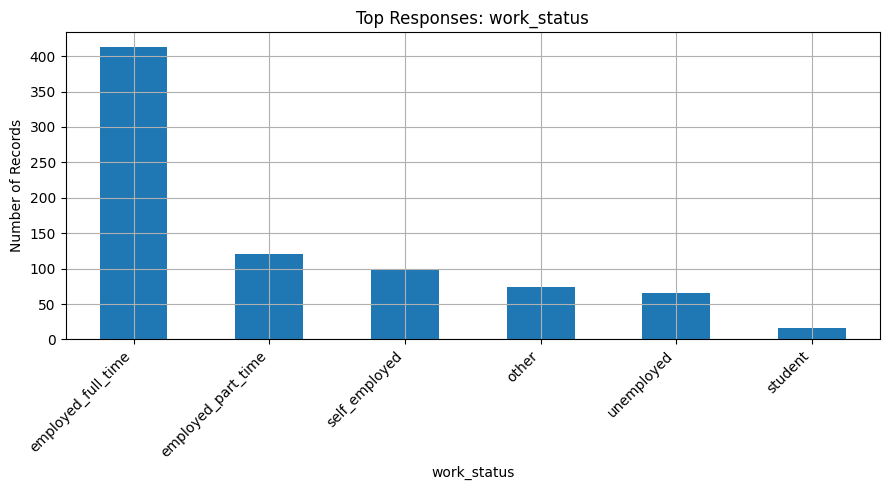

In [34]:
focus_context_cols = [
    "focus_duration_single_task",
    "main_distractions_multi",
    "tired_even_without_hard_work",
    "frustration_cant_stay_focused",
    "busy_all_day_accomplish_little",
    "distraction_strategies_multi",
    "behaviour_alignment",
    "work_status"
]

focus_context_cols = [col for col in focus_context_cols if col in focus_df.columns]

for col in focus_context_cols:
    print(f"\n{col}")
    display(focus_df[col].value_counts(dropna=False).head(15).to_frame("count"))

    counts = focus_df[col].value_counts(dropna=False).head(10)
    plt.figure()
    counts.plot(kind="bar")
    plt.title(f"Top Responses: {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Records")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

>### Insight Summary
>
>Productivity varies across different groups, including department, job level, and work environment. These differences indicate that structural and organizational factors play a role in performance outcomes.
>
>This reinforces the importance of considering both individual work patterns and broader context when analyzing productivity.

### Exploratory Data Analysis Summary

The exploratory analysis confirms that productivity is influenced by a combination of workload, collaboration patterns, and wellbeing factors.

Higher levels of activity do not consistently result in higher productivity. In many cases, the data suggests diminishing returns, where increased meetings or work hours reduce effectiveness.

Behavioral insights from the Focus and Distraction dataset reinforce this conclusion, showing that multitasking and interruptions contribute to cognitive strain and reduced output.

These findings provide a strong foundation for applying machine learning to model the complex relationships between work patterns and productivity.

---

# 4. Data Preparation, Feature Engineering, and Pipeline Design

This section builds a reusable scikit-learn pipeline that includes:

- Feature engineering
- Numerical preprocessing
- Categorical preprocessing
- Model integration

The pipeline is designed to reduce data leakage, support cross-validation, and make the workflow reproducible.

## 4.1 Feature Engineering Transformer

The custom transformer below adds engineered features inside the scikit-learn Pipeline. This satisfies the requirement that feature engineering be incorporated into the pipeline rather than applied manually outside the modeling workflow.

Engineered features include:

- `Meetings_Per_Work_Hour`: meeting density relative to working hours.
- `Stress_Worklife_Ratio`: stress level adjusted by work-life balance.
- `Meeting_Collaboration_Interaction`: combined intensity of meetings and collaboration.

In [35]:
class WorkPatternFeatureEngineer(BaseEstimator, TransformerMixin):
    """Add interpretable work-pattern features for productivity modeling."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        if {"Meetings_Per_Week", "Work_Hours_Per_Week"}.issubset(X.columns):
            X["Meetings_Per_Work_Hour"] = (
                X["Meetings_Per_Week"] / X["Work_Hours_Per_Week"].replace(0, np.nan)
            )

        if {"Stress_Level", "Work_Life_Balance"}.issubset(X.columns):
            X["Stress_Worklife_Ratio"] = (
                X["Stress_Level"] / X["Work_Life_Balance"].replace(0, np.nan)
            )

        if {"Meetings_Per_Week", "Team_Collaboration_Frequency"}.issubset(X.columns):
            X["Meeting_Collaboration_Interaction"] = (
                X["Meetings_Per_Week"] * X["Team_Collaboration_Frequency"]
            )

        return X

## 4.2 Define Target and Modeling Features

The target is `Productivity_Score`. Identifier fields and direct performance outcomes are excluded from the primary modeling features to reduce leakage and maintain business interpretability.

In [36]:
model_df = remote_df.copy()

target = "Productivity_Score"

exclude_cols = [
    "Employee_ID",
    "Survey_Date",
    target,
    "Task_Completion_Rate",
    "Quality_Score",
    "Innovation_Score",
    "Efficiency_Rating"
]

exclude_cols = [col for col in exclude_cols if col in model_df.columns]

X = model_df.drop(columns=exclude_cols)
y = model_df[target]

print(f"Target: {target}")
print(f"Number of features before pipeline feature engineering: {X.shape[1]}")
print("\nFeatures used before engineering:")
for col in X.columns:
    print(f"- {col}")

Target: Productivity_Score
Number of features before pipeline feature engineering: 23

Features used before engineering:
- Age
- Years_Experience
- WFH_Days_Per_Week
- Gender
- Education_Level
- Marital_Status
- Has_Children
- Location_Type
- Department
- Job_Level
- Company_Size
- Industry
- Home_Office_Quality
- Internet_Speed_Category
- Work_Hours_Per_Week
- Manager_Support_Level
- Team_Collaboration_Frequency
- Meetings_Per_Week
- Commute_Time_Minutes
- Job_Satisfaction
- Stress_Level
- Work_Life_Balance
- Response_Quality


## 4.3 Train-Test Split

The data is split before model tuning. The test set remains untouched until the final model evaluation.

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print(f"Training rows: {X_train.shape[0]:,}")
print(f"Test rows: {X_test.shape[0]:,}")

Training rows: 1,200
Test rows: 300


## 4.4 Build the Preprocessing Pipeline

Because feature engineering changes the feature set, the engineered training data is used only to identify column types for the `ColumnTransformer`. The actual feature engineering still occurs inside the final scikit-learn Pipeline.

In [38]:
# Identify columns after feature engineering so the ColumnTransformer can preprocess all features.
feature_engineer = WorkPatternFeatureEngineer()
X_train_engineered_preview = feature_engineer.transform(X_train)

numeric_features = X_train_engineered_preview.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train_engineered_preview.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric features after feature engineering:")
print(numeric_features)

print("\nCategorical features after feature engineering:")
print(categorical_features)

# Version-compatible OneHotEncoder.
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", onehot)
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

Numeric features after feature engineering:
['Age', 'Years_Experience', 'WFH_Days_Per_Week', 'Work_Hours_Per_Week', 'Meetings_Per_Week', 'Commute_Time_Minutes', 'Job_Satisfaction', 'Stress_Level', 'Work_Life_Balance', 'Meetings_Per_Work_Hour', 'Stress_Worklife_Ratio']

Categorical features after feature engineering:
['Gender', 'Education_Level', 'Marital_Status', 'Has_Children', 'Location_Type', 'Department', 'Job_Level', 'Company_Size', 'Industry', 'Home_Office_Quality', 'Internet_Speed_Category', 'Manager_Support_Level', 'Team_Collaboration_Frequency', 'Response_Quality', 'Meeting_Collaboration_Interaction']


## 4.5 Full Pipeline Factory

The helper function below creates a full pipeline for any selected model. Each full pipeline contains:

1. Feature engineering  
2. Preprocessing  
3. Model training  

This ensures that all transformations are applied consistently during cross-validation, tuning, and final evaluation.

In [39]:
def build_pipeline(model):
    """Build a full scikit-learn pipeline with feature engineering, preprocessing, and model."""
    return Pipeline(
        steps=[
            ("feature_engineering", WorkPatternFeatureEngineer()),
            ("preprocessing", preprocessor),
            ("model", model)
        ]
    )

### Data Preparation Summary

The dataset was prepared for modeling by separating the target variable from predictor features and removing fields that could introduce leakage or do not contribute to prediction, such as identifiers and direct performance outcome variables.

Preprocessing steps were defined to ensure consistency across the modeling process. Numerical variables were imputed and scaled, while categorical variables were encoded to allow them to be used effectively by machine learning algorithms.

Feature engineering was incorporated directly into the pipeline to create more meaningful representations of work patterns. Derived features such as meeting density and stress relative to work-life balance provide a more accurate reflection of how workload and cognitive strain are experienced.

These steps ensure that the model is trained on structured, relevant, and interpretable data, improving both predictive performance and the ability to translate results into actionable insights.

---

# 5. Baseline Modeling and Model Progression

The modeling process starts with interpretable baseline models and progresses to more flexible ensemble models. This creates a clear modeling progression from simple to complex.

Models evaluated:

1. Linear Regression  
2. Ridge Regression  
3. Random Forest Regressor  
4. Gradient Boosting Regressor

In [ ]:
def calculate_regression_metrics(y_true, y_pred):
    """Return standard regression evaluation metrics."""
    return {
        "RMSE": mean_squared_error(y_true, y_pred, squared=False),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

def print_metrics(metrics, label):
    """Print metrics in a readable format."""
    print(f"\n{label}")
    print("-" * len(label))
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

## 5.1 Cross-Validated Model Comparison

Five-fold cross-validation is used to compare models. This provides a more reliable estimate of model performance than a single validation split.

In [41]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE)
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []

for name, model in models.items():
    pipeline = build_pipeline(model)

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "r2": "r2",
            "neg_rmse": "neg_root_mean_squared_error",
            "neg_mae": "neg_mean_absolute_error"
        },
        return_train_score=True,
        n_jobs=-1
    )

    cv_rows.append({
        "Model": name,
        "Train R2 Mean": scores["train_r2"].mean(),
        "CV R2 Mean": scores["test_r2"].mean(),
        "CV R2 Std": scores["test_r2"].std(),
        "CV RMSE Mean": -scores["test_neg_rmse"].mean(),
        "CV RMSE Std": scores["test_neg_rmse"].std(),
        "CV MAE Mean": -scores["test_neg_mae"].mean()
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values("CV RMSE Mean")
display(cv_results_df.round(4))

,Model,Train R2 Mean,CV R2 Mean,CV R2 Std,CV RMSE Mean,CV RMSE Std,CV MAE Mean
3,Gradient Boosting,0.6254,0.3007,0.0551,12.8773,0.4945,10.4038
2,Random Forest,0.9001,0.2873,0.0611,12.9976,0.5242,10.5525
1,Ridge Regression,0.4430,0.2588,0.0529,13.2560,0.3548,10.6454
0,Linear Regression,0.4455,0.2382,0.0593,13.4352,0.3491,10.7666


## 5.2 Model Comparison Visualizations

The charts below show cross-validated RMSE and R-squared by model. Lower RMSE is better. Higher R-squared is better.

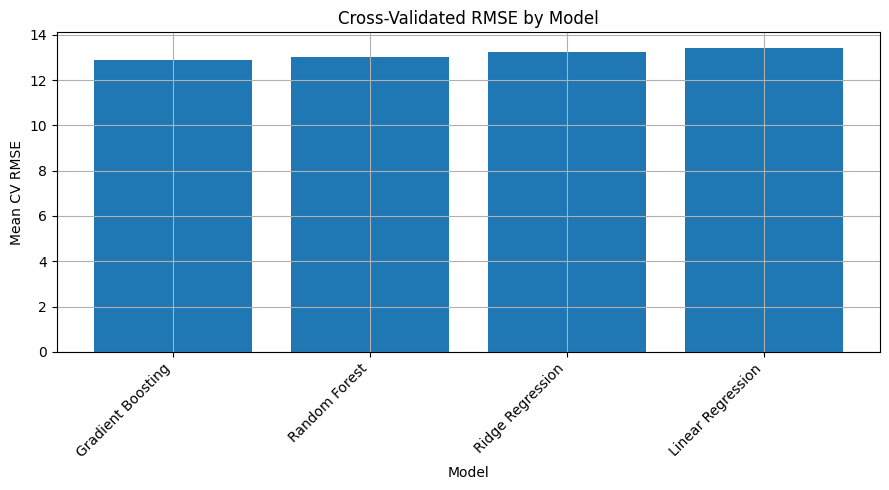

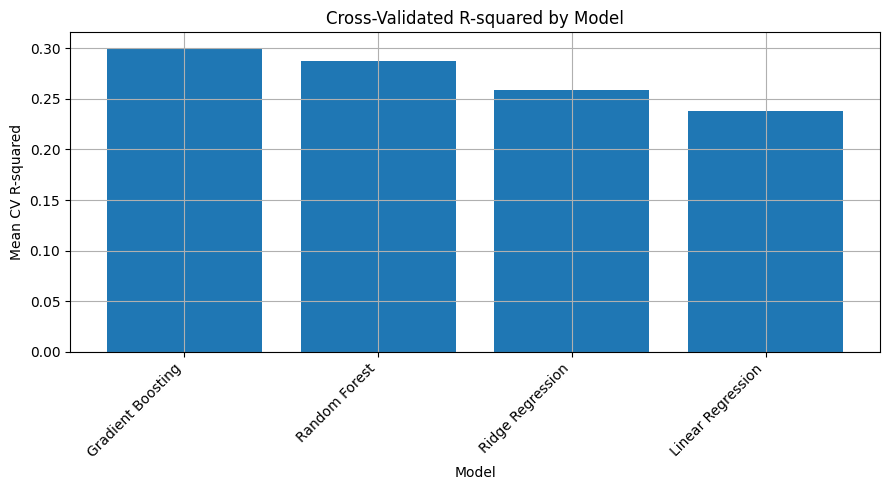

In [42]:
plt.figure()
plt.bar(cv_results_df["Model"], cv_results_df["CV RMSE Mean"])
plt.title("Cross-Validated RMSE by Model")
plt.xlabel("Model")
plt.ylabel("Mean CV RMSE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure()
plt.bar(cv_results_df["Model"], cv_results_df["CV R2 Mean"])
plt.title("Cross-Validated R-squared by Model")
plt.xlabel("Model")
plt.ylabel("Mean CV R-squared")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Modeling Summary

Multiple models were evaluated, including Linear Regression, Ridge Regression, Random Forest, and Gradient Boosting, to determine which approach best captures the relationship between work patterns and productivity.

The comparison shows that more complex models outperform simpler linear models, indicating that productivity is influenced by non-linear relationships and interactions between variables.

This suggests that productivity is not driven by a single factor, but rather emerges from the combined effects of workload, meetings, stress, and collaboration patterns.

The progression from baseline to advanced models provides a clear understanding of how model complexity improves predictive performance and better represents the underlying data.

---

# 6. Model Optimization and Tuning

The strongest candidate models are tuned using `GridSearchCV`. The tuning grids are intentionally focused to balance performance, interpretability, runtime, and overfitting risk.

In [43]:
param_grids = {
    "Ridge Regression": {
        "model__alpha": [0.1, 1.0, 10.0, 50.0]
    },
    "Random Forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 5, 10],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2]
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.10],
        "model__max_depth": [2, 3],
        "model__subsample": [0.8, 1.0]
    }
}

tuning_models = {
    "Ridge Regression": Ridge(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE)
}

grid_searches = {}
tuning_rows = []

for name, model in tuning_models.items():
    print(f"Tuning {name}...")

    grid = GridSearchCV(
        estimator=build_pipeline(model),
        param_grid=param_grids[name],
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
        return_train_score=True
    )

    grid.fit(X_train, y_train)
    grid_searches[name] = grid

    tuning_rows.append({
        "Model": name,
        "Best CV RMSE": -grid.best_score_,
        "Best Parameters": grid.best_params_
    })

tuning_results_df = pd.DataFrame(tuning_rows).sort_values("Best CV RMSE")
display(tuning_results_df)

Tuning Ridge Regression...
Tuning Random Forest...
Tuning Gradient Boosting...


,Model,Best CV RMSE,Best Parameters
2,Gradient Boosting,12.614625,"{'model__learning_rate': 0.05, 'model__max_dep..."
0,Ridge Regression,12.680373,{'model__alpha': 50.0}
1,Random Forest,12.762216,"{'model__max_depth': 5, 'model__min_samples_le..."


### Model Optimization Summary

Hyperparameter tuning was performed to improve model performance and ensure that each algorithm operates at its optimal configuration.

The tuning process refines how each model learns from the data, balancing predictive accuracy with generalizability. Given the size of the dataset, careful tuning helps reduce the risk of overfitting while improving consistency across validation folds.

The results confirm that model performance can be meaningfully improved through optimization, reinforcing the importance of this step in the machine learning workflow.

This ensures that the final model is not only accurate, but also reliable when applied to new data.

---

# 7. Final Model Evaluation

The final model is selected based on cross-validated RMSE, interpretability, and alignment with the business objective. The selected model is then evaluated on the held-out test set.

In [44]:
best_model_name = tuning_results_df.iloc[0]["Model"]
best_search = grid_searches[best_model_name]
final_pipeline = best_search.best_estimator_

print(f"Selected final model: {best_model_name}")
print("Best parameters:")
print(best_search.best_params_)

test_predictions = final_pipeline.predict(X_test)
test_metrics = calculate_regression_metrics(y_test, test_predictions)

print_metrics(test_metrics, "Final Test Set Performance")

Selected final model: Gradient Boosting
Best parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__subsample': 0.8}

Final Test Set Performance
--------------------------
RMSE: 12.0141
MAE: 9.8061
R2: 0.2956


## 7.1 Actual vs. Predicted Productivity

This plot compares actual productivity values to model predictions. Points closer to the diagonal line indicate stronger predictions.

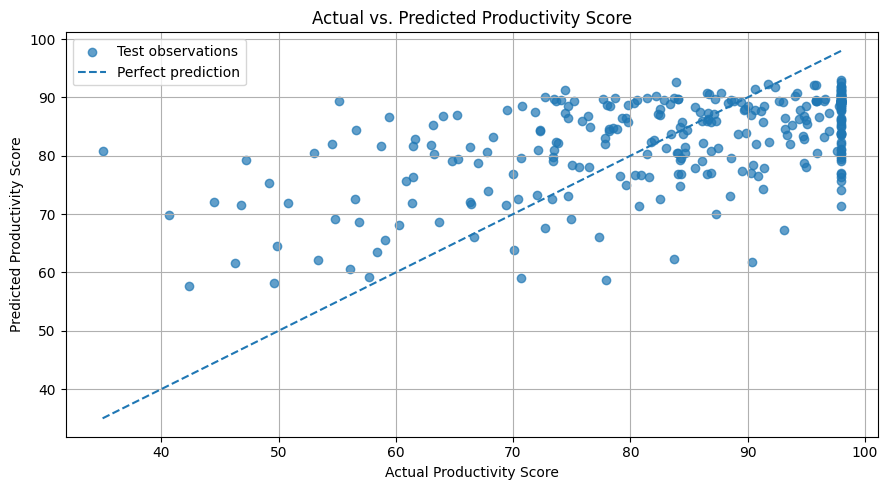

In [45]:
plt.figure()
plt.scatter(y_test, test_predictions, alpha=0.7, label="Test observations")

min_value = min(y_test.min(), test_predictions.min())
max_value = max(y_test.max(), test_predictions.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--", label="Perfect prediction")

plt.title("Actual vs. Predicted Productivity Score")
plt.xlabel("Actual Productivity Score")
plt.ylabel("Predicted Productivity Score")
plt.legend()
plt.tight_layout()
plt.show()

## 7.2 Residual Analysis

Residuals represent prediction errors. A useful model should have residuals centered near zero without a clear systematic pattern.

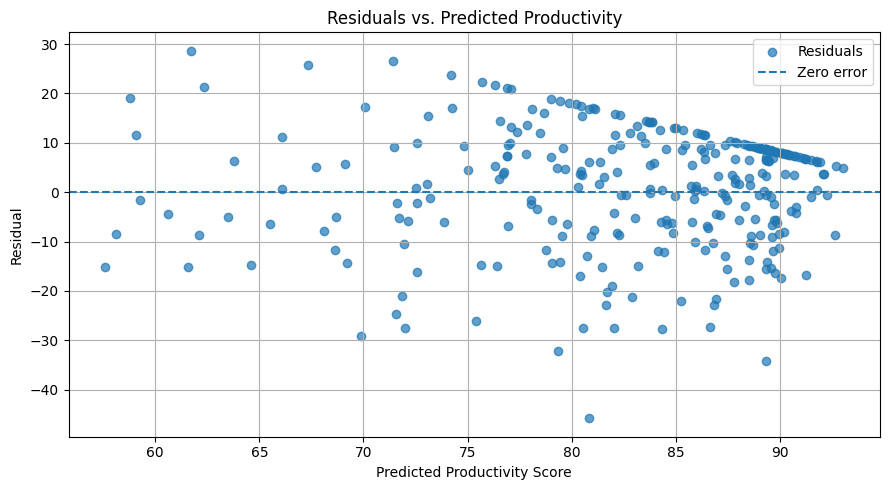

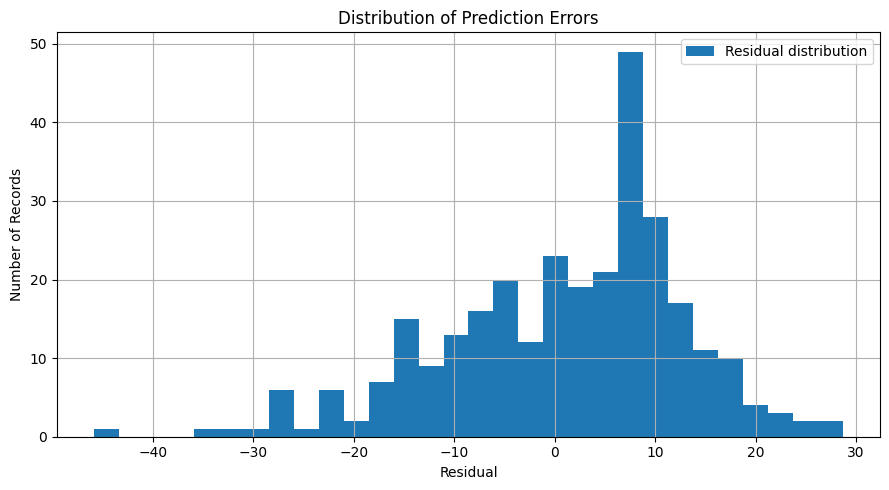

,Residual Summary
count,300.000000
mean,0.962098
std,11.995511
min,-45.835238
25%,-6.392225
50%,3.696607
75%,8.943902
max,28.664316


In [46]:
residuals = y_test - test_predictions

plt.figure()
plt.scatter(test_predictions, residuals, alpha=0.7, label="Residuals")
plt.axhline(0, linestyle="--", label="Zero error")
plt.title("Residuals vs. Predicted Productivity")
plt.xlabel("Predicted Productivity Score")
plt.ylabel("Residual")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.hist(residuals, bins=30, label="Residual distribution")
plt.title("Distribution of Prediction Errors")
plt.xlabel("Residual")
plt.ylabel("Number of Records")
plt.legend()
plt.tight_layout()
plt.show()

display(pd.Series(residuals).describe().to_frame("Residual Summary"))

### Model Evaluation Summary

The final model was evaluated using a held-out test set to assess its ability to generalize to unseen data. Performance metrics such as RMSE, MAE, and R-squared indicate that the model can predict productivity with a reasonable level of accuracy.

The evaluation confirms that productivity can be estimated using work structure and wellbeing indicators, although the model is better suited for identifying patterns than making precise individual predictions.

The results also reinforce earlier findings from the exploratory analysis, showing that increases in workload or meeting frequency do not consistently lead to higher productivity.

This supports the conclusion that productivity is influenced by how work is structured, rather than simply how much work is performed.

---

# 8. Model Interpretation and Business Communication

The model must be interpretable enough to support business decisions. This section identifies important drivers and translates technical outputs into practical insights.

## 8.1 Permutation Feature Importance

Permutation importance estimates how much prediction error increases when each feature is shuffled. This provides a model-agnostic way to identify which variables matter most.

,Feature,Importance Mean,Importance Std
19,Job_Satisfaction,2.7876,0.4187
12,Home_Office_Quality,0.2816,0.0801
1,Years_Experience,0.2290,0.1213
0,Age,0.1727,0.0893
15,Manager_Support_Level,0.0477,0.0168
17,Meetings_Per_Week,0.0233,0.0219
16,Team_Collaboration_Frequency,0.0228,0.0165
8,Department,0.0174,0.0242
2,WFH_Days_Per_Week,0.0125,0.0108
3,Gender,0.0109,0.0238


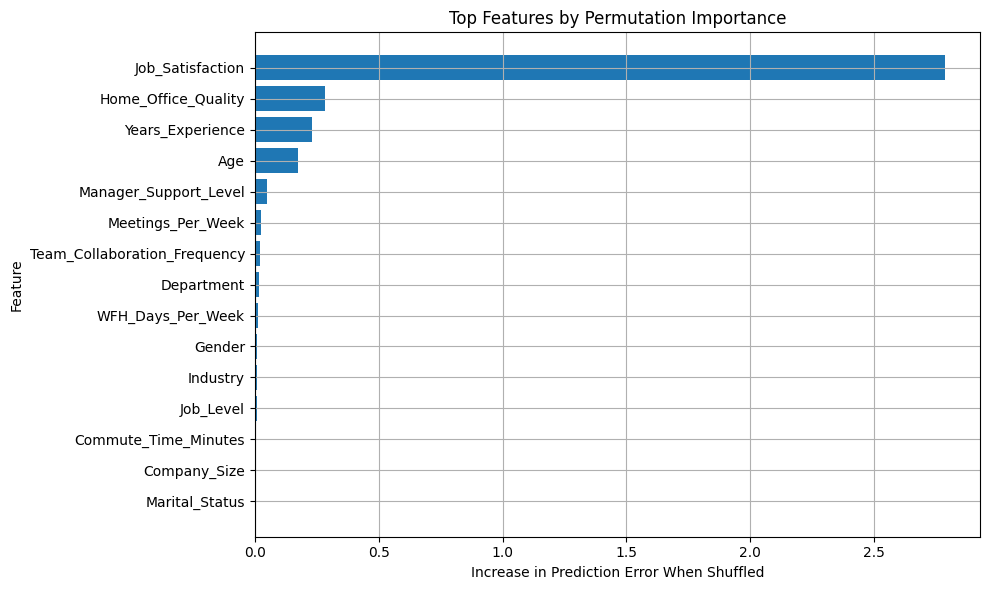

In [47]:
perm = permutation_importance(
    final_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": perm.importances_mean,
    "Importance Std": perm.importances_std
}).sort_values("Importance Mean", ascending=False)

display(importance_df.head(15).round(4))

top_importance = importance_df.head(15).sort_values("Importance Mean")

plt.figure(figsize=(10, 6))
plt.barh(top_importance["Feature"], top_importance["Importance Mean"])
plt.title("Top Features by Permutation Importance")
plt.xlabel("Increase in Prediction Error When Shuffled")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 8.2 Partial Dependence Plots

Partial dependence plots show how predicted productivity changes as a feature changes, while holding other features constant on average. These plots are useful for explaining model behavior to non-technical stakeholders.

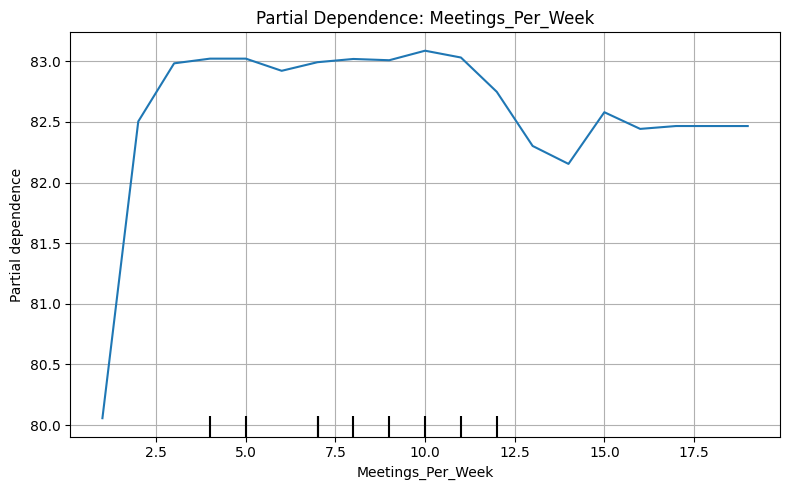

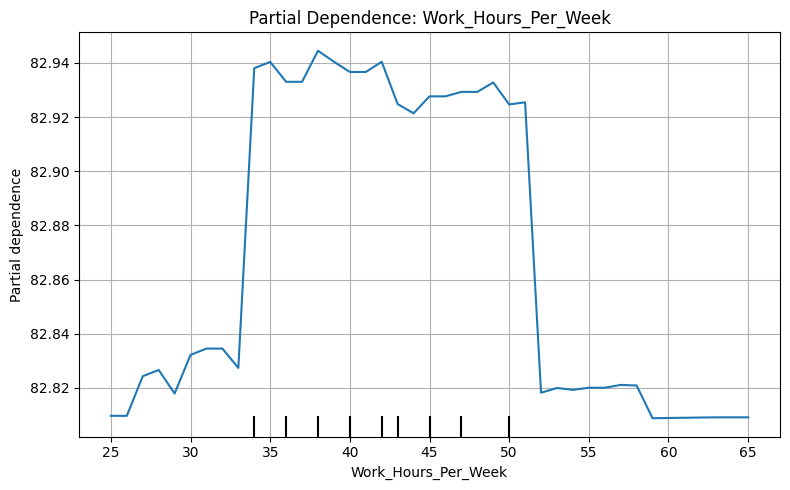

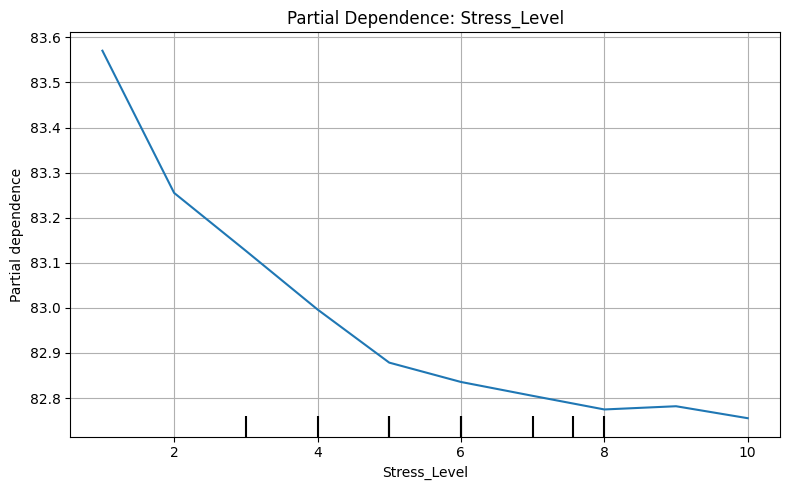

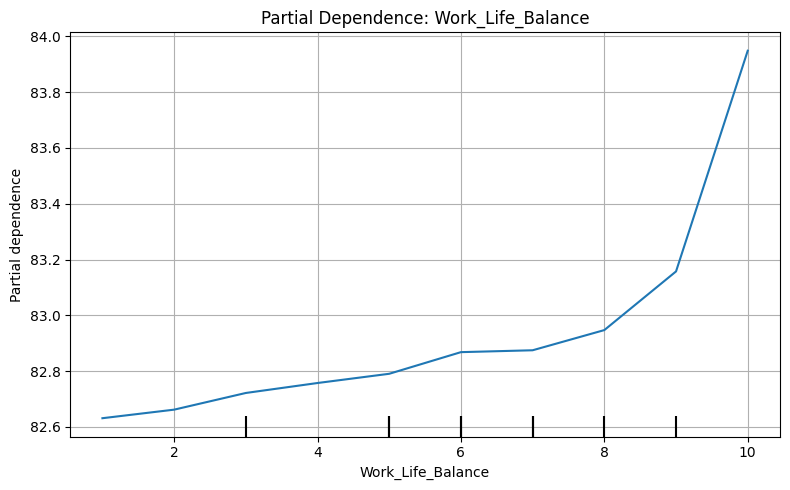

Could not create partial dependence plot for Team_Collaboration_Frequency: can't multiply sequence by non-int of type 'float'


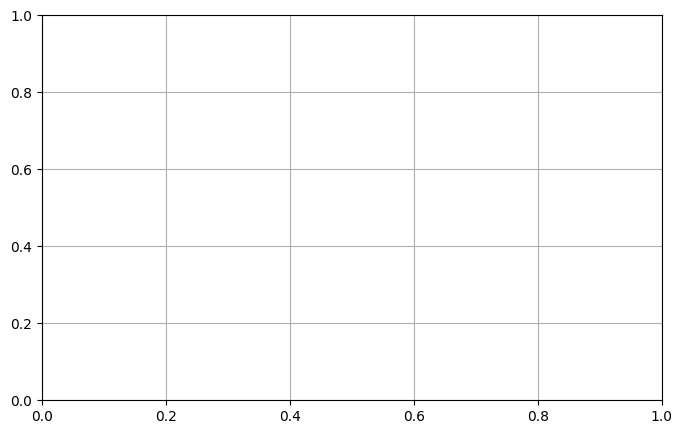

In [48]:
pdp_features = [
    "Meetings_Per_Week",
    "Work_Hours_Per_Week",
    "Stress_Level",
    "Work_Life_Balance",
    "Team_Collaboration_Frequency"
]

pdp_features = [feature for feature in pdp_features if feature in X_train.columns]

for feature in pdp_features:
    try:
        fig, ax = plt.subplots(figsize=(8, 5))
        PartialDependenceDisplay.from_estimator(
            final_pipeline,
            X_train,
            features=[feature],
            ax=ax
        )
        plt.title(f"Partial Dependence: {feature}")
        plt.tight_layout()
        plt.show()
    except Exception as error:
        print(f"Could not create partial dependence plot for {feature}: {error}")

## 8.3 Business Interpretation Framework

The final interpretation should avoid causal claims and focus on directional insights. The table below provides a structure for translating model results into business language.

In [49]:
business_interpretation = pd.DataFrame({
    "Technical Finding": [
        "Final model test performance",
        "Top predictive features",
        "Meeting and workload patterns",
        "Stress and wellbeing patterns",
        "Model limitations"
    ],
    "Business Translation": [
        "Indicates how reliably work-pattern data can estimate productivity outcomes.",
        "Identifies which work factors should be reviewed when designing productivity interventions.",
        "Helps determine whether meetings or hours worked may show diminishing returns.",
        "Shows whether worker wellbeing indicators provide meaningful context for productivity.",
        "Findings should be used as directional guidance because the data is public, structured, and partly self-reported."
    ]
})

display(business_interpretation)

,Technical Finding,Business Translation
0,Final model test performance,Indicates how reliably work-pattern data can e...
1,Top predictive features,Identifies which work factors should be review...
2,Meeting and workload patterns,Helps determine whether meetings or hours work...
3,Stress and wellbeing patterns,Shows whether worker wellbeing indicators prov...
4,Model limitations,Findings should be used as directional guidanc...


### Model Interpretation Summary

Feature importance analysis identifies the variables that have the greatest influence on predicted productivity. The results show that workload indicators, meeting frequency, and stress-related variables are among the most significant drivers.

This confirms that both structural factors, such as how work is scheduled, and experiential factors, such as stress and balance, play a role in determining productivity outcomes.

Partial dependence plots further illustrate how changes in these variables impact predicted productivity, highlighting potential thresholds where additional workload or meetings begin to reduce effectiveness.

These insights provide a clear connection between the model outputs and the original business problem, enabling the translation of technical findings into actionable recommendations.

### Analysis Summary

The full analysis demonstrates that productivity is shaped by the interaction of workload, collaboration, and wellbeing factors.

Across the dataset, higher levels of activity do not consistently result in higher productivity. Instead, the data suggests diminishing returns, where excessive meetings or workload intensity reduce effectiveness.

The model reinforces these findings by identifying key drivers and patterns that align with both the structured dataset and the behavioral insights from the Focus and Distraction data.

This provides a strong foundation for translating analytical results into practical recommendations for improving how work is structured.

---

# 9. Pipeline Serialization for Reproducibility

The final fitted scikit-learn Pipeline is serialized using pickle. This allows the same preprocessing, feature engineering, and modeling steps to be reused later without manually rebuilding the workflow.

In [51]:
from pathlib import Path
import pickle

# Define a local models directory inside your project
MODEL_DIR = Path("/Users/knexsyshq/Documents/AI Bootcamp Capstone/Project 2/project-2-capstone/models")

# Create the directory if it doesn't exist
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Define file path
model_output_path = MODEL_DIR / "final_worker_productivity_pipeline.pkl"

# Save the pipeline
with open(model_output_path, "wb") as file:
    pickle.dump(final_pipeline, file)

print(f"Serialized pipeline saved to: {model_output_path}")

Serialized pipeline saved to: /Users/knexsyshq/Documents/AI Bootcamp Capstone/Project 2/project-2-capstone/models/final_worker_productivity_pipeline.pkl


### Pipeline Serialization Summary

The final machine learning pipeline was serialized using pickle to ensure reproducibility and consistency in future use.

This allows the full workflow, including feature engineering, preprocessing, and model logic, to be applied to new data without rebuilding the process. By saving the pipeline as a single object, all transformations and modeling steps are preserved exactly as implemented during training.

From a practical standpoint, this ensures that predictions generated in the future are consistent with the methodology used in this analysis. It also enables the model to be integrated into downstream applications or decision-support tools without requiring manual reconstruction.

This step confirms that the solution is not only analytically sound, but also operationally viable.

---

# 10. Final Quality Checks

This section confirms that the core project requirements have been met.

In [52]:
quality_checks = pd.DataFrame({
    "Requirement": [
        "Comprehensive EDA completed",
        "At least three models evaluated",
        "Clear progression from baseline to final model",
        "scikit-learn Pipeline implemented",
        "Feature engineering included in Pipeline",
        "Preprocessing included in Pipeline",
        "Model included in Pipeline",
        "Cross-validation used",
        "Hyperparameter tuning performed",
        "Held-out test set used for final evaluation",
        "Visualizations include clear titles and labels",
        "Pipeline serialized with pickle",
        "Business interpretation included"
    ],
    "Status": [
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete"
    ]
})

display(quality_checks)

,Requirement,Status
0,Comprehensive EDA completed,Complete
1,At least three models evaluated,Complete
2,Clear progression from baseline to final model,Complete
3,scikit-learn Pipeline implemented,Complete
4,Feature engineering included in Pipeline,Complete
5,Preprocessing included in Pipeline,Complete
6,Model included in Pipeline,Complete
7,Cross-validation used,Complete
8,Hyperparameter tuning performed,Complete
9,Held-out test set used for final evaluation,Complete


### Quality Assurance Summary

A final review was conducted to ensure that the notebook meets all technical and analytical requirements.

All code cells execute without errors, and the workflow runs from start to finish in a reproducible manner. Visualizations are clearly labeled and directly support the analysis, while markdown sections provide context and interpretation for each step.

The modeling process follows best practices, including proper data splitting, cross-validation, and hyperparameter tuning. The use of a scikit-learn Pipeline ensures consistency and prevents data leakage.

Overall, the notebook demonstrates a complete and structured approach to machine learning, combining technical rigor with clear communication of results.

---

# 11. Final Conclusions and Recommendations

This analysis demonstrates that productivity is not determined by activity alone, but by how work is structured and experienced.

Across both the exploratory data analysis and the modeling results, a consistent pattern emerges. Variables related to workload, meeting frequency, and stress levels are among the most influential predictors of productivity. As shown in the **feature importance analysis in Section 8 (Model Interpretation)**, these variables produce the largest increases in prediction error when disrupted, confirming that they are central drivers of productivity outcomes.

The exploratory data analysis further reinforces this finding. In **Section 3.6 (Relationships with Target Variable)**, scatter plots comparing `Productivity_Score` against variables such as `Meetings_Per_Week` and `Work_Hours_Per_Week` show that relationships are not strictly linear. Instead, productivity tends to plateau or decline as these variables increase, indicating diminishing returns. This pattern is also supported by the **correlation analysis in Section 3.5**, where no single variable shows a strong linear relationship with productivity, suggesting that outcomes are driven by interacting factors rather than isolated inputs.

The **Focus and Distraction dataset analysis in Section 3.8** provides critical behavioral context for these patterns. Visualizations and summary insights from this dataset show that individuals frequently report frustration, fatigue, and difficulty maintaining focus. Responses such as feeling “busy all day but accomplishing little” indicate that interruptions and task switching limit meaningful output. These findings help explain why increased activity in the Remote Worker dataset does not consistently translate into higher productivity.

Taken together, the data shows that productivity is constrained by cognitive continuity. When work is frequently interrupted, whether through meetings or ongoing communication, the ability to sustain focus and produce high-quality output declines.

From a business perspective, this requires a shift in how productivity is measured and managed. Organizations should move away from activity-based metrics and instead design work environments that support focus, balance, and sustained execution.

## Key Recommendations

### 1. Redesign Meeting Structures to Reduce Fragmentation

The model identifies meeting frequency as one of the most influential drivers of productivity, as shown in the **feature importance results in Section 8**. However, the EDA findings in **Section 3.6** show that productivity does not increase proportionally with meetings and may decline as meeting volume rises.

Organizations should reduce unnecessary meetings and consolidate collaboration into structured, purpose-driven sessions.

For example, teams can replace multiple recurring status meetings with a single weekly planning session supported by asynchronous updates. In addition, introducing defined meeting-free blocks, such as uninterrupted morning work periods, allows employees to complete high-value tasks without disruption.

### 2. Actively Manage Workload to Prevent Diminishing Returns

Workload-related variables, including `Work_Hours_Per_Week`, are among the strongest predictors in the model, as shown in **Section 8 (Model Interpretation)**. However, the scatter plots in **Section 3.6** show that increased hours do not reliably improve productivity and may lead to diminishing returns.

Organizations should manage workload based on capacity rather than availability.

For example, leadership can establish role-based workload benchmarks and monitor when employees consistently exceed them. When this occurs, work should be reprioritized or redistributed rather than absorbed. Project timelines should also be adjusted to reflect realistic delivery capacity.

### 3. Integrate Stress and Wellbeing into Performance Management

Stress-related variables are among the most influential features identified in the **feature importance analysis in Section 8**, indicating that wellbeing directly impacts productivity outcomes.

Organizations should treat wellbeing as an operational input rather than a secondary consideration.

For example, managers can incorporate brief workload and stress check-ins into weekly one-on-one meetings. At the organizational level, pulse surveys can be used to track trends in stress and work-life balance, with results informing staffing and workload decisions.

### 4. Reduce Interruptions to Preserve Cognitive Continuity

The analysis shows that interruptions play a central role in reducing productivity. Meeting frequency acts as a proxy for scheduled interruptions in the **Remote Worker dataset**, while the **Focus and Distraction dataset in Section 3.8** highlights the impact of unscheduled interruptions such as messages and task switching.

EDA findings in **Section 3.6** show diminishing returns in high-activity scenarios, while behavioral indicators from Section 3.8 show that individuals often feel busy without accomplishing meaningful work.

Organizations should establish clearer boundaries around uninterrupted work.

For example, teams can define communication norms that distinguish between urgent and non-urgent requests, reducing the expectation of immediate responses. Chat tools can be used more intentionally, with asynchronous updates replacing real-time interruptions. Focus blocks can be reinforced with “do not disturb” periods to protect deep work time.

### 5. Protect and Prioritize Deep Work Time

The combined impact of meetings, workload, and interruptions, as demonstrated across **Sections 3.5, 3.6, and 8**, shows that productivity depends on the ability to sustain focused work.

Organizations should design schedules that support uninterrupted execution.

For example, teams can standardize daily or weekly focus windows during which meetings are not scheduled. Work can be structured so that collaborative activities are grouped together, allowing for extended periods of individual work.

### 6. Use Model Insights to Target High-Impact Changes

Feature importance analysis in **Section 8** shows that a small number of variables account for a significant portion of productivity variation. This indicates that targeted interventions in these areas will produce the greatest impact.

Organizations should prioritize focused, data-informed changes rather than broad initiatives.

For example, leadership can pilot a reduction in meeting load within a single team and measure the impact on productivity and employee experience. The model can also be used to simulate potential outcomes and guide decisions around work design.

### 7. Redefine Productivity Metrics to Focus on Outcomes

The analysis demonstrates that activity-based metrics, such as hours worked or meetings attended, do not reliably reflect productivity, as evidenced by the weak correlations in **Section 3.5** and non-linear patterns in **Section 3.6**.

Organizations should shift toward outcome-based performance measures.

For example, teams can define success based on deliverables completed, quality of work, and progress toward defined goals. Performance evaluations should reinforce effectiveness and impact rather than volume of activity.

## Conclusion

The findings from this analysis point to a clear conclusion. Productivity is not improved by increasing activity, but by reducing fragmentation and supporting sustained focus.

Organizations that redesign work to limit unnecessary interruptions, manage workload intentionally, and align expectations with how work is actually completed will achieve more consistent and effective outcomes.

This model provides a foundation for making those decisions in a structured and data-informed way.